# Customer Churn Prediction & Retention Strategy

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    chi2_contingency,
    kruskal,
    skew,
    kurtosis,
    uniform as sp_randFloat,
    randint as sp_randInt,
)

from imblearn.over_sampling import SMOTE

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

## Data Loading and Initial Inspection

In [2]:
df = pd.read_csv(r'C:\Users\wlgus\OneDrive\바탕 화면\chrun_rate\Data\cell2celltrain.csv')
df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [3]:
print("n_duplicated :", len(df[df.duplicated()])) 

n_duplicated : 0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [5]:
# Summary statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,51047.0,3.201957e+06,116905.561666,3000002.00,3100632.00,3201534.00,3305376.000,3399994.00
MonthlyRevenue,50891.0,5.883449e+01,44.507336,-6.17,33.61,48.46,71.065,1223.38
MonthlyMinutes,50891.0,5.256534e+02,529.871063,0.00,158.00,366.00,723.000,7359.00
TotalRecurringCharge,50891.0,4.683009e+01,23.848871,-11.00,30.00,45.00,60.000,400.00
DirectorAssistedCalls,50891.0,8.952290e-01,2.228546,0.00,0.00,0.25,0.990,159.39
OverageMinutes,50891.0,4.002778e+01,96.588076,0.00,0.00,3.00,41.000,4321.00
RoamingCalls,50891.0,1.236244e+00,9.818294,0.00,0.00,0.00,0.300,1112.40
PercChangeMinutes,50680.0,-1.154791e+01,257.514772,-3875.00,-83.00,-5.00,66.000,5192.00
PercChangeRevenues,50680.0,-1.191985e+00,39.574915,-1107.70,-7.10,-0.30,1.600,2483.50
DroppedCalls,51047.0,6.011489e+00,9.043955,0.00,0.70,3.00,7.700,221.70


In [6]:
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(exclude="object").columns

print(f"Number of categorical features: {len(categorical_cols)}")
print(f"Number of numerical features: {len(numerical_cols)}")

print("\nCategorical features:")
print(list(categorical_cols))

print("\nNumerical features:")
print(list(numerical_cols))

Number of categorical features: 23
Number of numerical features: 35

Categorical features:
['Churn', 'ServiceArea', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'HandsetPrice', 'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus']

Numerical features:
['CustomerID', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'Handset

In [7]:
# Convert numerical variables that represent categories into categorical data types.
# These variables represent grouped categories rather than continuous numerical values.

categorical_features_to_convert = [
    "IncomeGroup",
    "ReferralsMadeBySubscriber",
    "HandsetModels"
]

for col in categorical_features_to_convert:
    df[col] = df[col].astype("object")

In [8]:
# Verify data types after conversion
df[categorical_features_to_convert].dtypes

IncomeGroup                  object
ReferralsMadeBySubscriber    object
HandsetModels                object
dtype: object

In [9]:
# Calculate the percentage of missing values for each feature.
missing_ratio = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .rename("Missing Ratio")
)

# Display the top 10 features with the highest missing ratios.
missing_ratio.head(10)

AgeHH2                   0.017807
AgeHH1                   0.017807
PercChangeMinutes        0.007189
PercChangeRevenues       0.007189
MonthlyRevenue           0.003056
MonthlyMinutes           0.003056
TotalRecurringCharge     0.003056
DirectorAssistedCalls    0.003056
OverageMinutes           0.003056
RoamingCalls             0.003056
Name: Missing Ratio, dtype: float64

In [10]:
# Summarize missing values across the dataset.
print(f"Features with missing values: {(missing_ratio > 0).sum()}")
print(f"Maximum missing ratio: {missing_ratio.max():.1%}")

Features with missing values: 14
Maximum missing ratio: 1.8%


In [11]:
# Examine the quality of the HandsetPrice feature.
handset_price_counts = df["HandsetPrice"].value_counts(dropna=False)
unknown_ratio = (df["HandsetPrice"] == "Unknown").mean()

print(f"Missing ratio: {df['HandsetPrice'].isna().mean():.1%}")
print(f"Unknown ratio: {unknown_ratio:.1%}")

handset_price_counts.head(10)

Missing ratio: 0.0%
Unknown ratio: 56.8%


HandsetPrice
Unknown    28982
30          7328
150         4115
130         2105
80          1960
10          1928
60          1776
200         1266
100         1235
40           249
Name: count, dtype: int64

In [12]:
# Remove HandsetPrice because a large proportion of its values are recorded as "Unknown",
# making the feature unreliable for predictive modeling.
df = df.drop(columns="HandsetPrice")

In [13]:
# Identify categorical and numerical features.
categorical_features = df.select_dtypes(include="object").columns.tolist()
numerical_features = df.select_dtypes(exclude="object").columns.tolist()

print(f"Number of observations: {len(df):,}")
print(f"Total number of columns: {df.shape[1]}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")

Number of observations: 51,047
Total number of columns: 57
Categorical features: 25
Numerical features: 32


In [14]:
# Display feature names by data type.
print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Churn', 'ServiceArea', 'HandsetModels', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'OwnsMotorcycle', 'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus']

Numerical features:
['CustomerID', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'CurrentEquipmentDays', 'AgeHH1'

In [15]:
# Summarize features with missing values only.
missing_summary = (
    pd.DataFrame({
        "Missing Count": df.isna().sum(),
        "Missing Ratio (%)": (df.isna().mean() * 100).round(2)
    })
    .query("`Missing Count` > 0")
    .sort_values(by="Missing Ratio (%)", ascending=False)
)

print(f"Features with missing values: {len(missing_summary)}")

missing_summary

Features with missing values: 14


,Missing Count,Missing Ratio (%)
AgeHH1,909,1.78
AgeHH2,909,1.78
PercChangeMinutes,367,0.72
PercChangeRevenues,367,0.72
MonthlyRevenue,156,0.31
MonthlyMinutes,156,0.31
TotalRecurringCharge,156,0.31
DirectorAssistedCalls,156,0.31
OverageMinutes,156,0.31
RoamingCalls,156,0.31


## Data Overview

In [16]:
# Display a high-level summary of the dataset.
print(f"Number of observations: {len(df):,}")
print(f"Number of features: {df.shape[1]}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Numerical features: {len(numerical_features)}")
print(f"Features with missing values: {(df.isna().sum() > 0).sum()}")
print(f"Duplicate records: {df.duplicated().sum()}")

Number of observations: 51,047
Number of features: 57
Categorical features: 25
Numerical features: 32
Features with missing values: 14
Duplicate records: 0


## Target Variable Exploration

C:\Users\wlgus\AppData\Local\Temp\ipykernel_26236\2633843875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


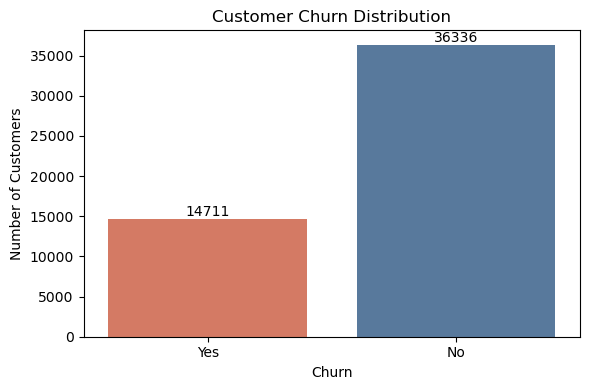

In [17]:
# Visualize the distribution of the target variable.
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x="Churn",
    palette=["#E76F51", "#4C78A8"]
)

# Display the count on top of each bar.
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [18]:
# Summarize the class distribution.
churn_summary = (
    pd.DataFrame({
        "Count": df["Churn"].value_counts(),
        "Percentage (%)": (
            df["Churn"]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
    })
)

churn_summary

,Count,Percentage (%)
Churn,,
No,36336,71.18
Yes,14711,28.82


### Insight

- The dataset shows a moderate class imbalance, with non-churn customers representing the majority class.
- To reduce prediction bias toward the majority class, class imbalance will be addressed during model development using SMOTE.

## Feature Analysis

### Categorical Feature Analysis

In [19]:
# Create a list of categorical predictors by excluding the target variable.
categorical_predictors = [
    col for col in categorical_features
    if col != "Churn"
]

In [20]:
# Summarize the number of unique values for each categorical predictor.
unique_summary = (
    df[categorical_predictors]
    .nunique()
    .sort_values()
    .rename("Unique Values")
    .to_frame()
)

unique_summary

,Unique Values
NonUSTravel,2
MadeCallToRetentionTeam,2
ChildrenInHH,2
HandsetRefurbished,2
HandsetWebCapable,2
TruckOwner,2
RVOwner,2
Homeownership,2
BuysViaMailOrder,2
RespondsToMailOffers,2


In [21]:
# Remove CustomerID because it is a unique identifier and does not provide predictive information.
df = df.drop(columns="CustomerID")

# Update feature lists after removing CustomerID.
categorical_features = df.select_dtypes(include="object").columns.tolist()
numerical_features = df.select_dtypes(exclude="object").columns.tolist()

# Create a list of categorical predictors by excluding the target variable.
categorical_predictors = [
    col for col in categorical_features
    if col != "Churn"
]

In [22]:
# Summarize missing values in categorical predictors.
categorical_missing = (
    pd.DataFrame({
        "Missing Count": df[categorical_predictors].isna().sum(),
        "Missing Ratio (%)": (
            df[categorical_predictors].isna().mean() * 100
        ).round(2)
    })
    .query("`Missing Count` > 0")
    .sort_values(by="Missing Ratio (%)", ascending=False)
)

categorical_missing

,Missing Count,Missing Ratio (%)
ServiceArea,24,0.05
HandsetModels,1,0.00


In [23]:
# Check the proportion of missing values in ServiceArea.
service_area_missing = df["ServiceArea"].isna().mean()

print(f"Missing ratio: {service_area_missing:.2%}")

Missing ratio: 0.05%


In [24]:
# Remove rows with missing ServiceArea values.
# ServiceArea represents geographic information and cannot be reliably imputed.
# Since only 0.05% of records have missing values, those rows are removed.
df = df.dropna(subset=["ServiceArea"])

In [25]:
# Verify that missing values in categorical predictors have been handled.
categorical_missing = (
    df[categorical_predictors]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

categorical_missing

HandsetModels                1
ServiceArea                  0
Occupation                   0
PrizmCode                    0
CreditRating                 0
MadeCallToRetentionTeam      0
OwnsMotorcycle               0
IncomeGroup                  0
ReferralsMadeBySubscriber    0
NotNewCellphoneUser          0
NewCellphoneUser             0
HasCreditCard                0
OwnsComputer                 0
NonUSTravel                  0
OptOutMailings               0
RespondsToMailOffers         0
BuysViaMailOrder             0
Homeownership                0
RVOwner                      0
TruckOwner                   0
HandsetWebCapable            0
HandsetRefurbished           0
ChildrenInHH                 0
MaritalStatus                0
dtype: int64

In [26]:
# Check the proportion of missing values in HandsetModels.
handset_models_missing = df["HandsetModels"].isna().mean()

print(f"Missing ratio: {handset_models_missing:.2%}")

Missing ratio: 0.00%


In [27]:
# Remove rows with missing HandsetModels values.
df = (
    df
    .dropna(subset=["HandsetModels"])
    .reset_index(drop=True)
)

### Distribution of Categorical Features

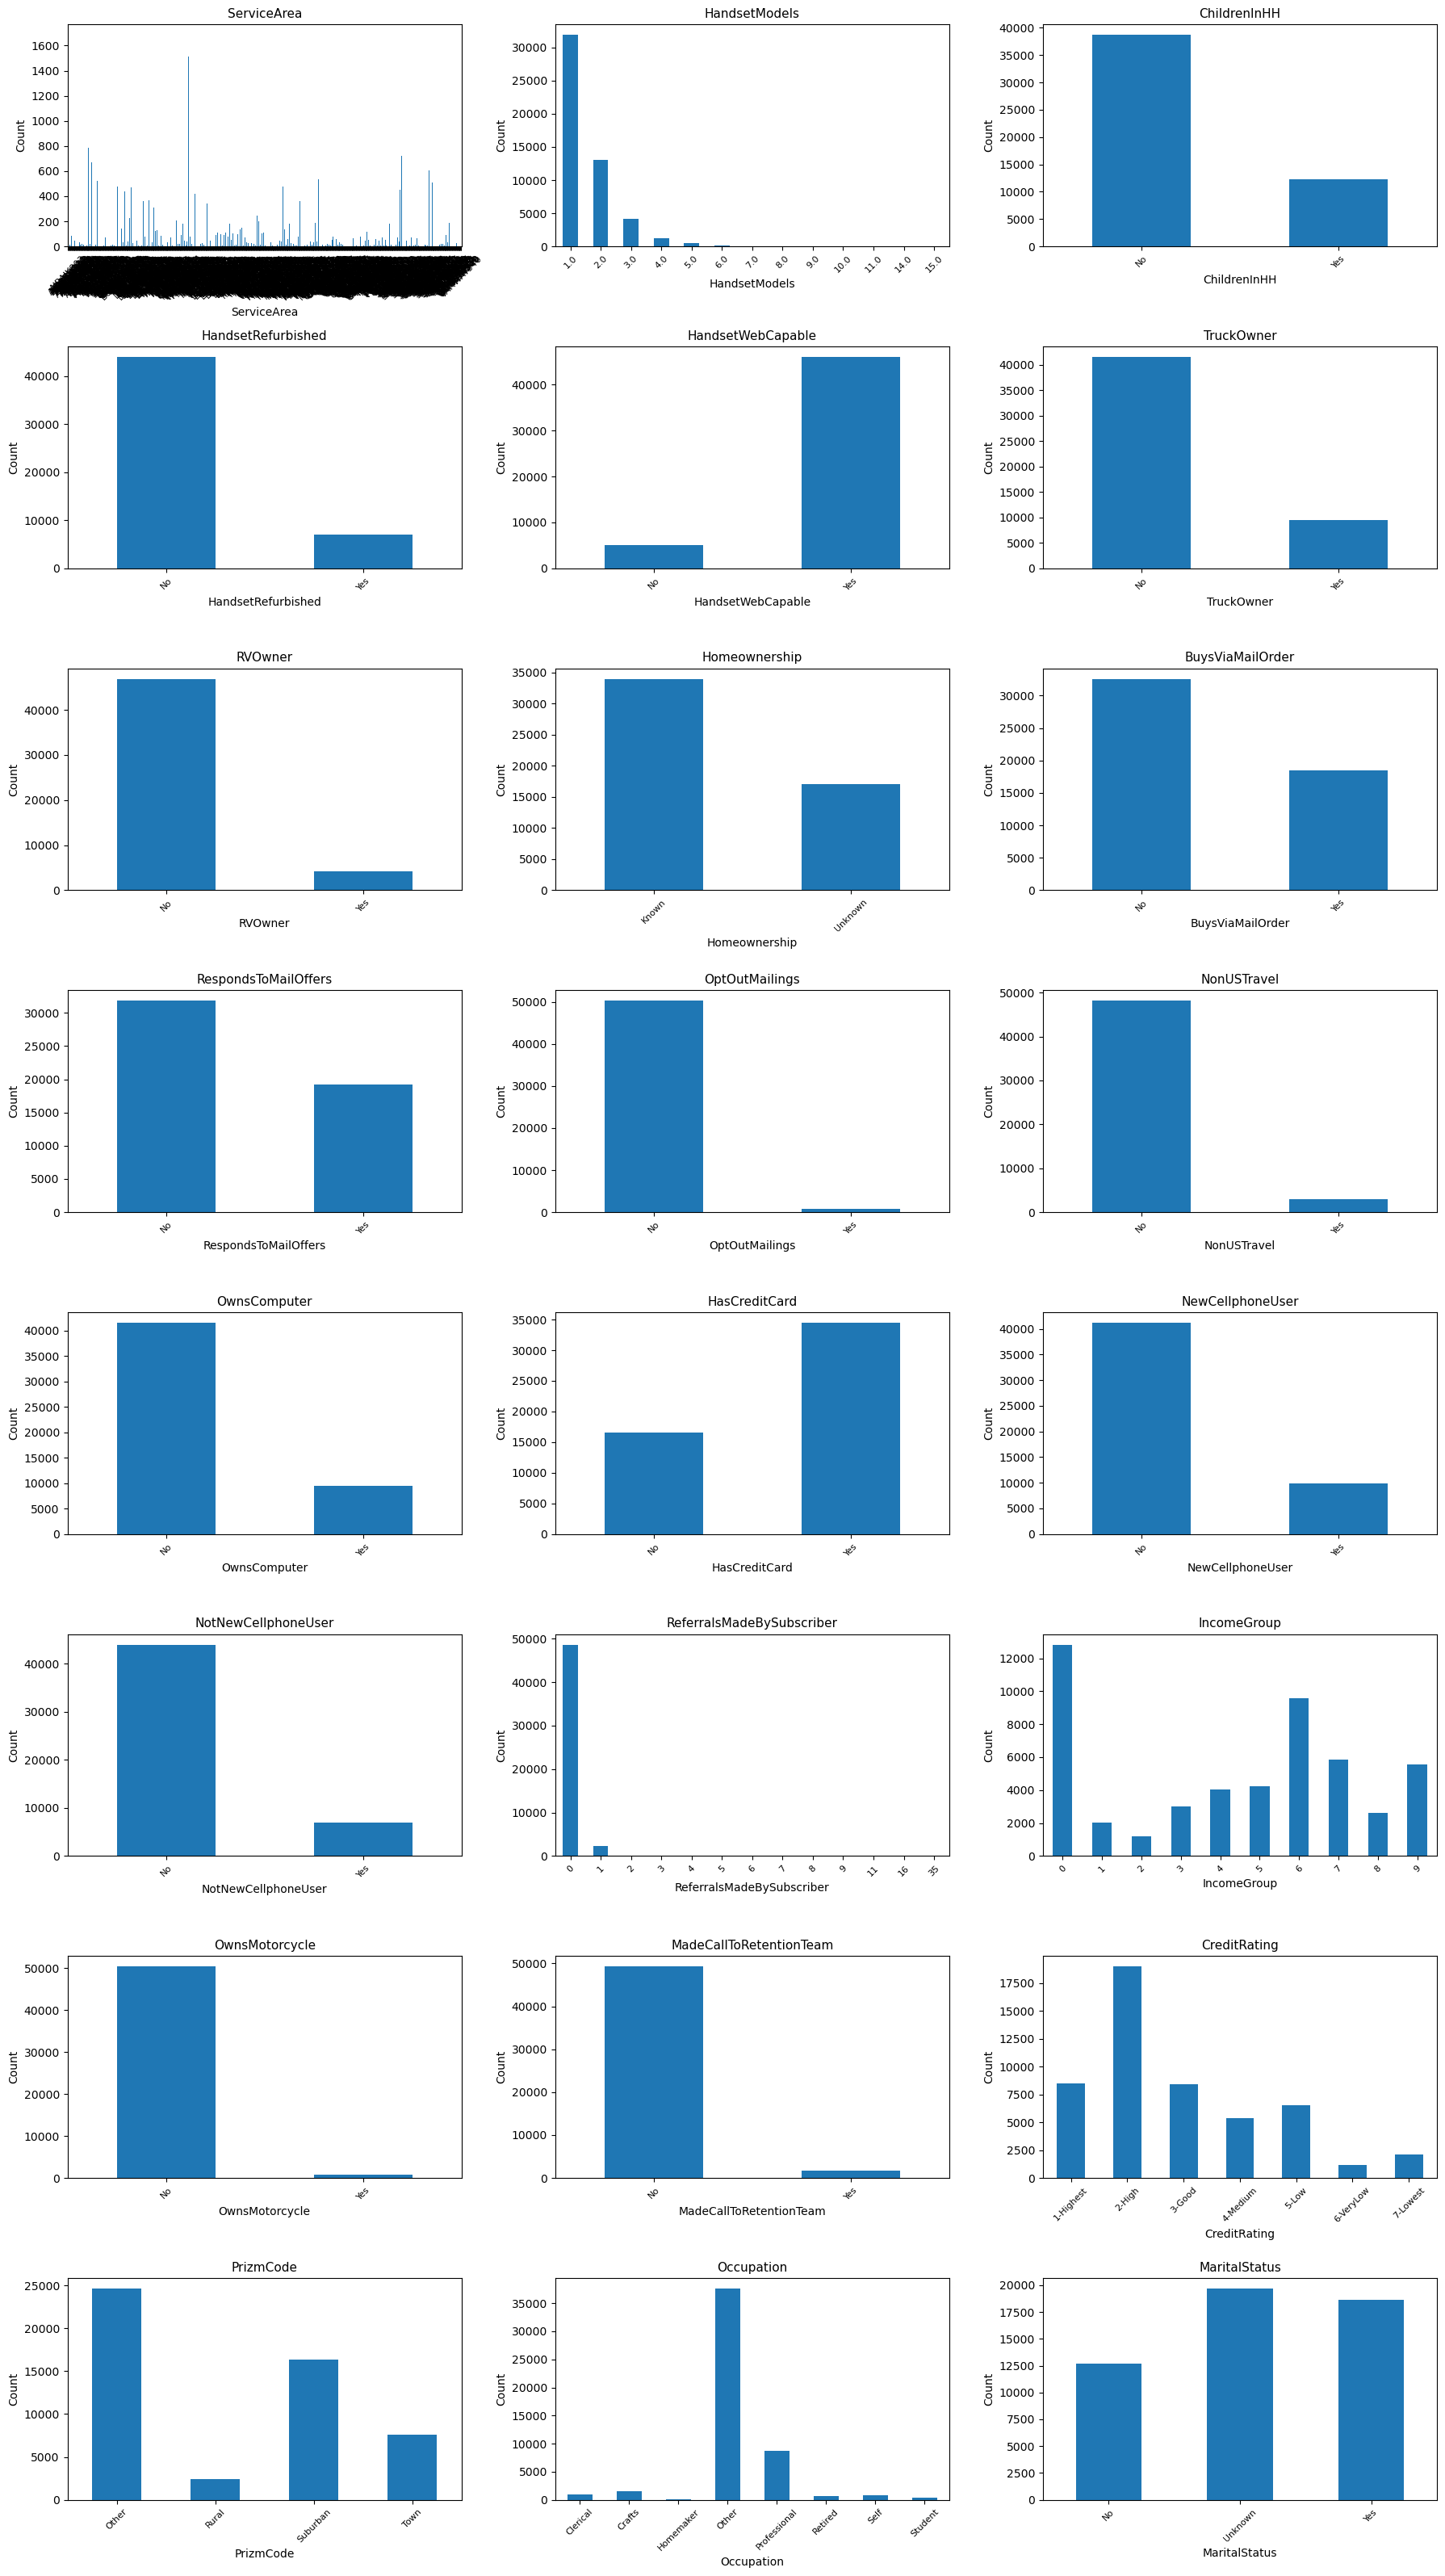

In [28]:
# Visualize the distribution of categorical predictors.
n_features = len(categorical_predictors)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(categorical_predictors, 1):
    plt.subplot(n_rows, n_cols, i)

    (
        df[col]
        .value_counts()
        .sort_index()
        .plot(kind="bar")
    )

    plt.title(col, fontsize=11)
    plt.xticks(rotation=45, fontsize=8)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Categorical Features vs. Churn

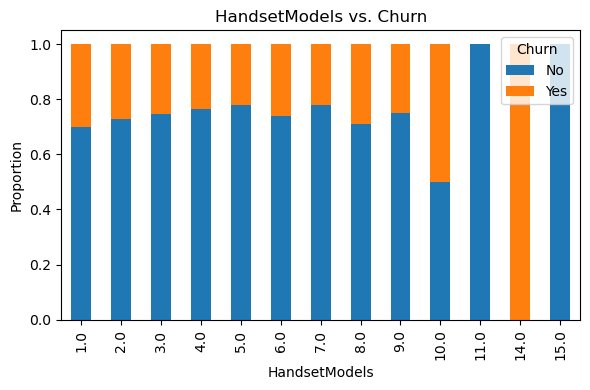

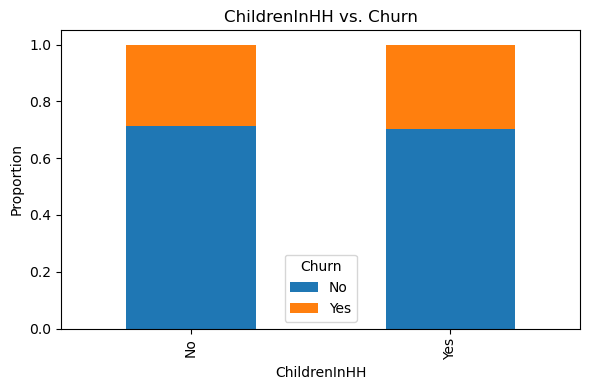

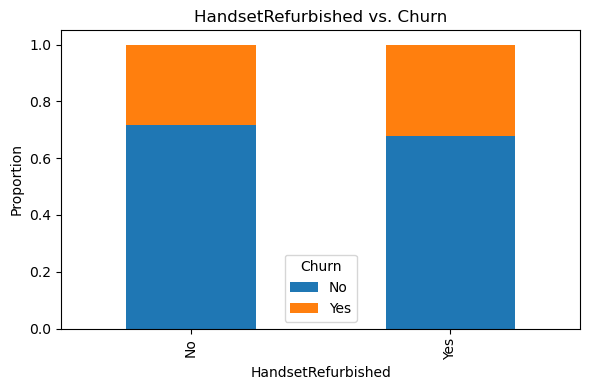

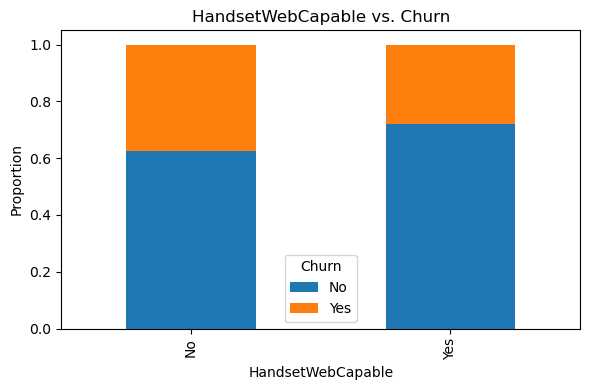

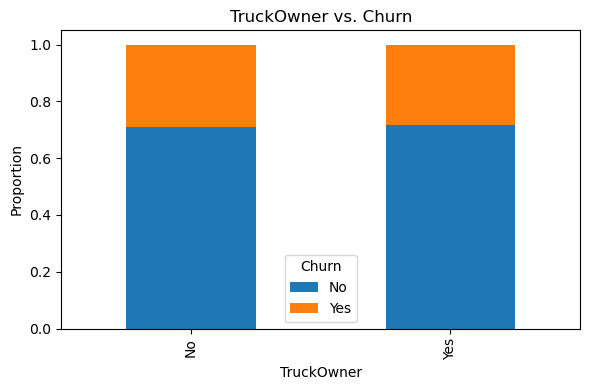

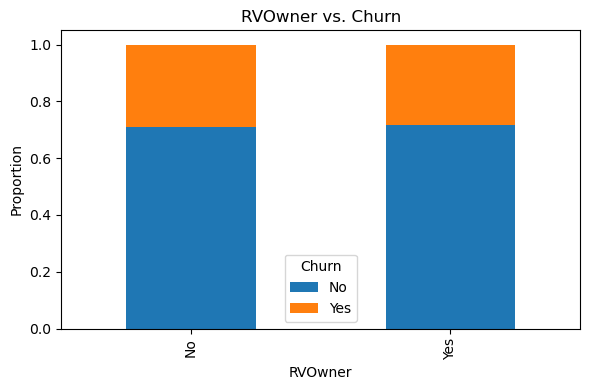

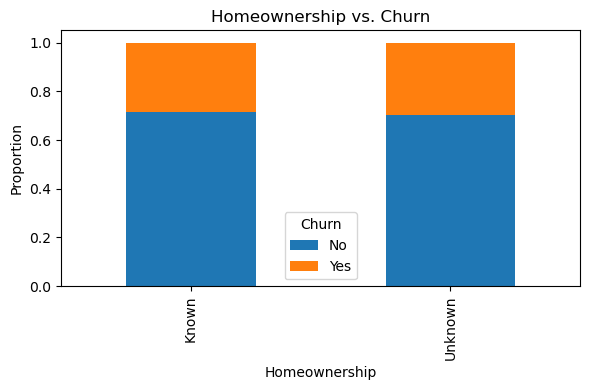

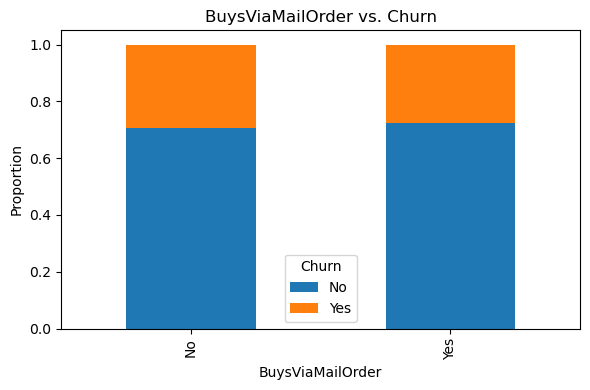

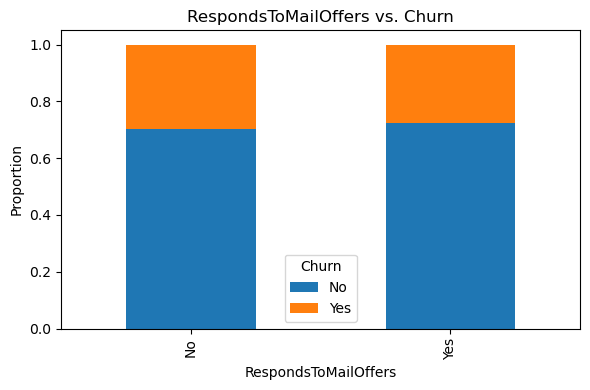

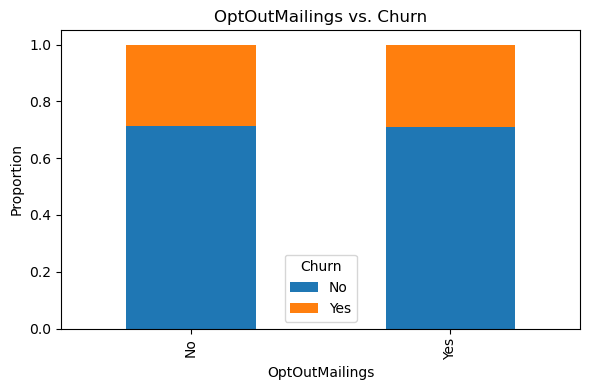

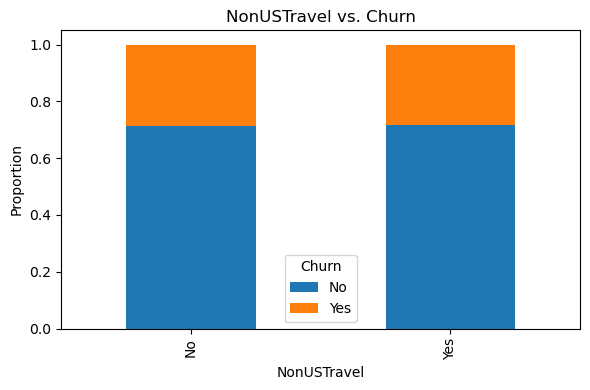

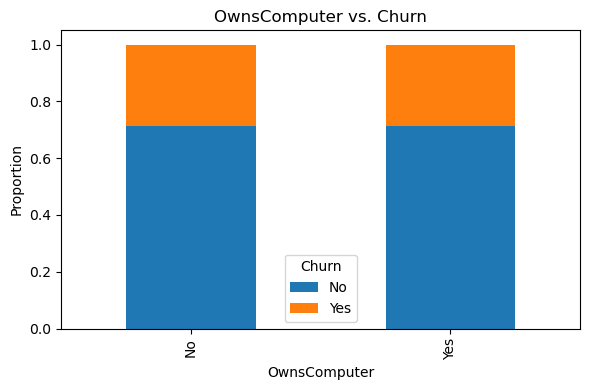

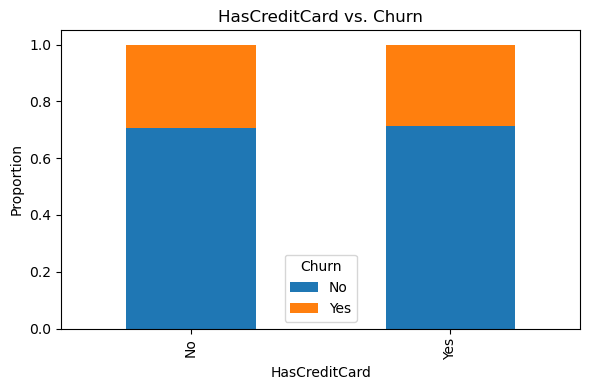

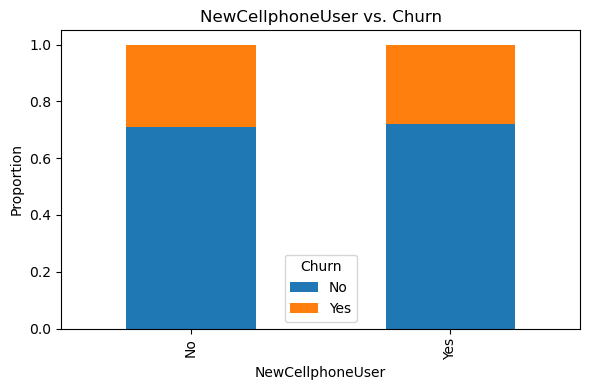

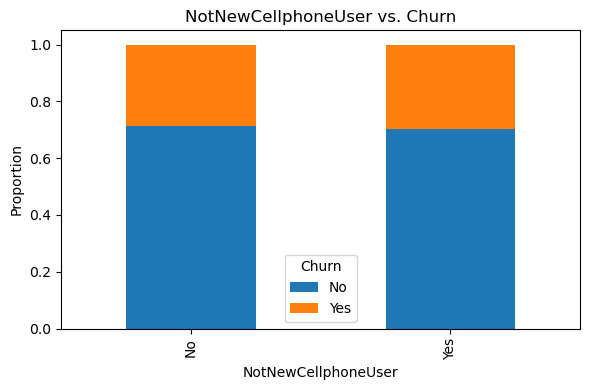

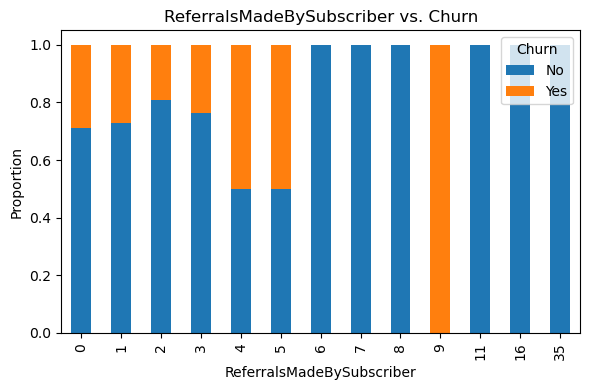

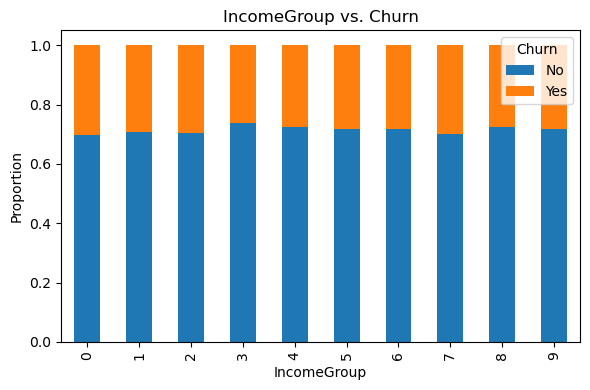

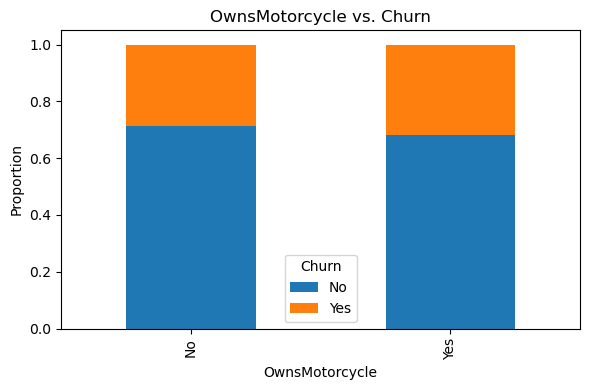

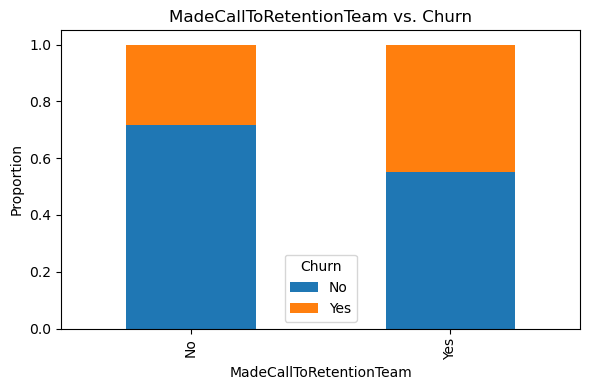

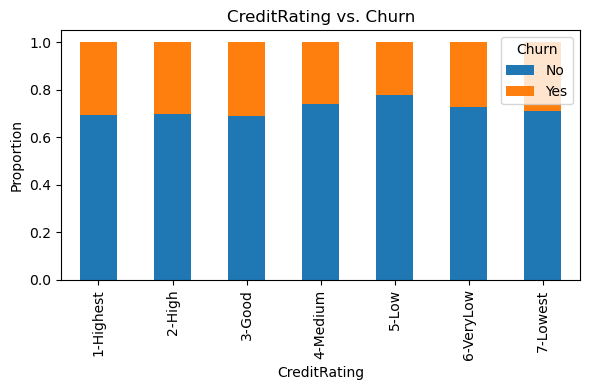

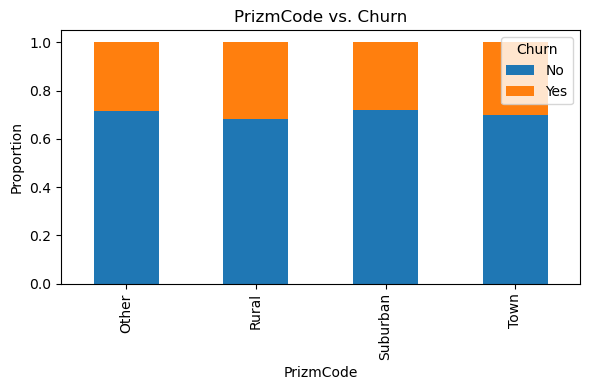

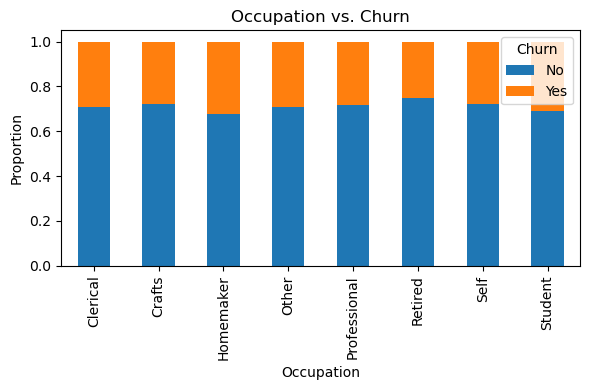

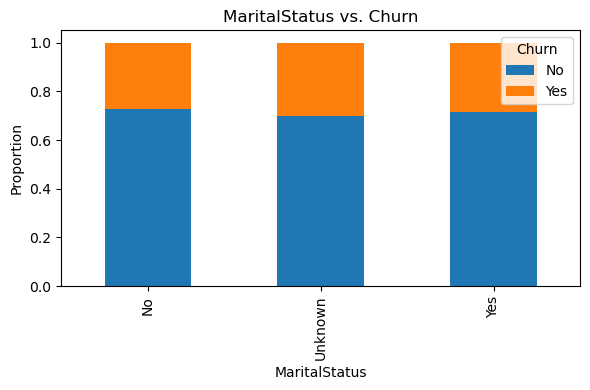

In [29]:
# Exclude the high-cardinality feature from visualization to improve readability.
plot_categorical_features = [
    col for col in categorical_predictors
    if col != "ServiceArea"
]

# Visualize the relationship between categorical predictors and customer churn.
for col in plot_categorical_features:
    churn_ratio = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    )

    churn_ratio.plot(
        kind="bar",
        stacked=True,
        figsize=(6, 4)
    )

    plt.title(f"{col} vs. Churn")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

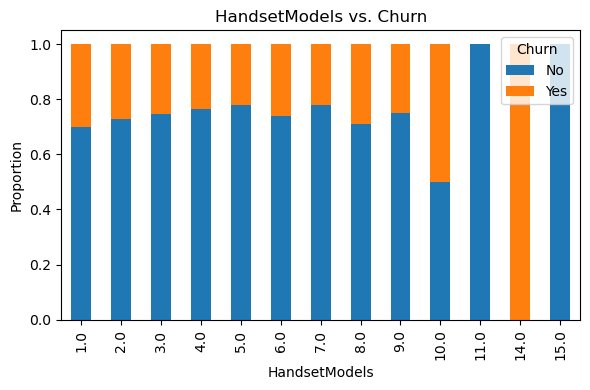

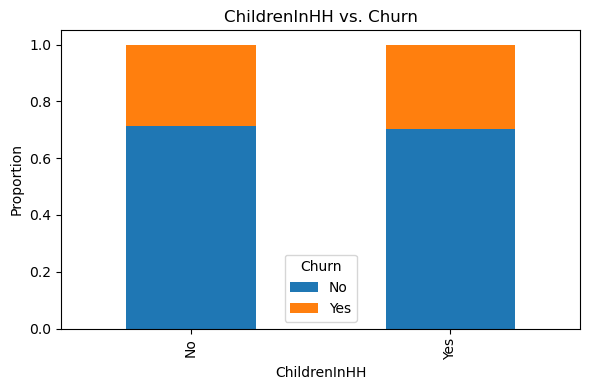

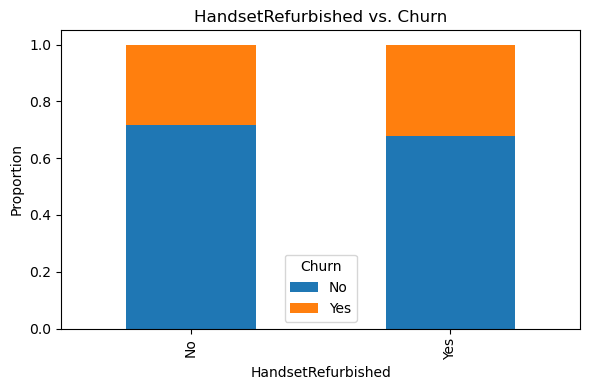

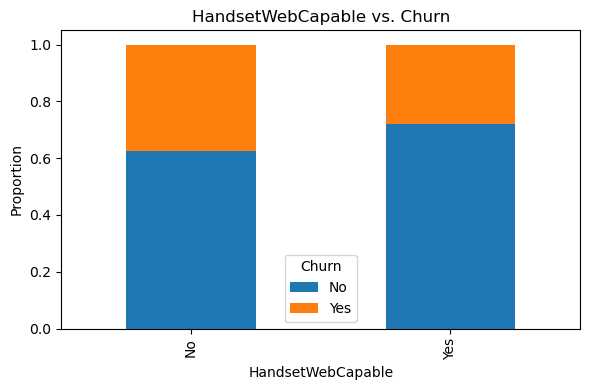

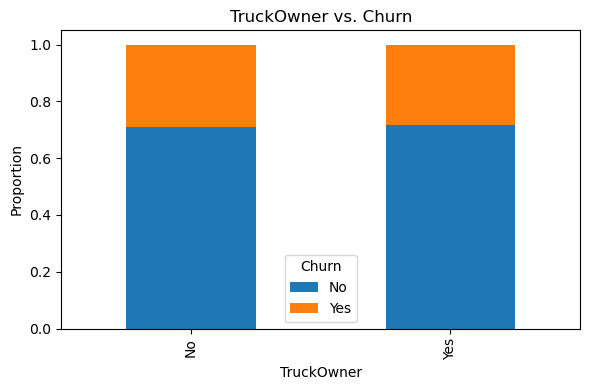

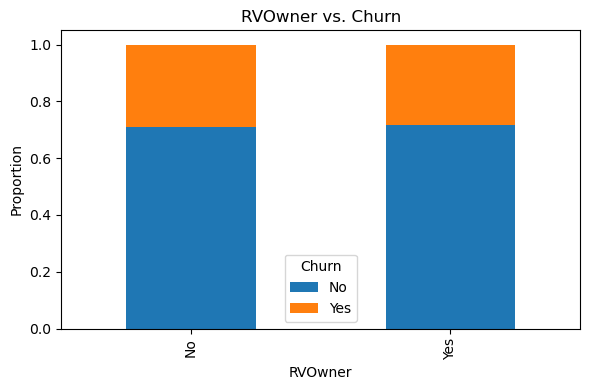

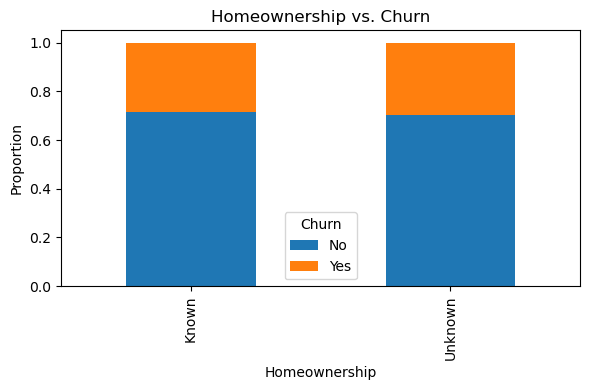

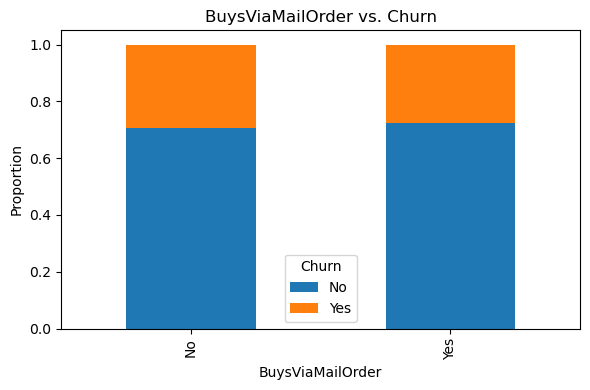

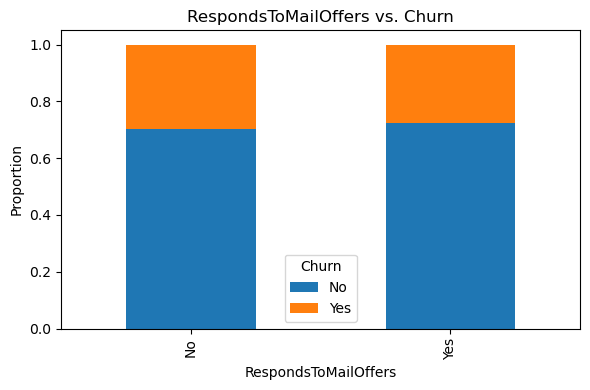

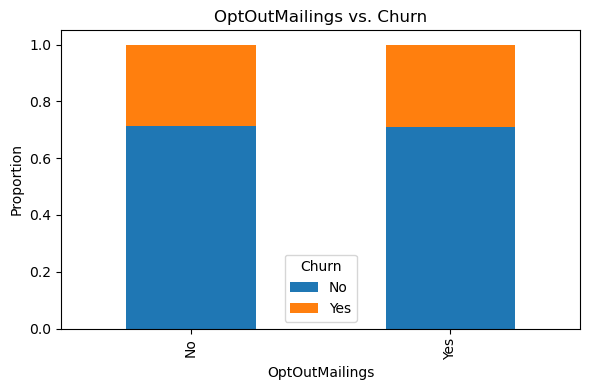

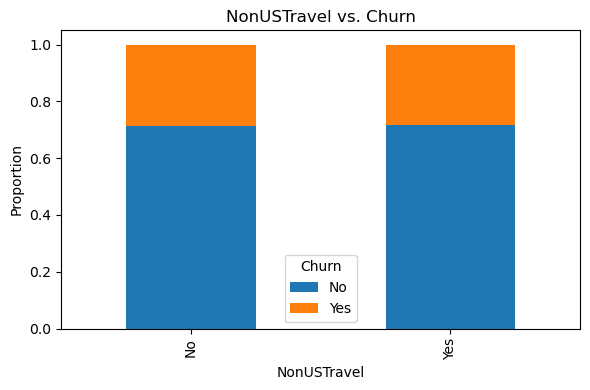

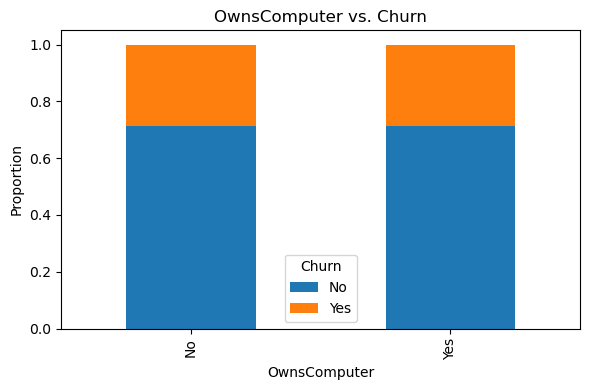

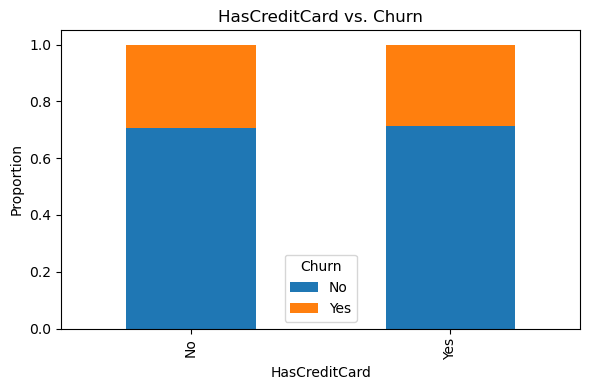

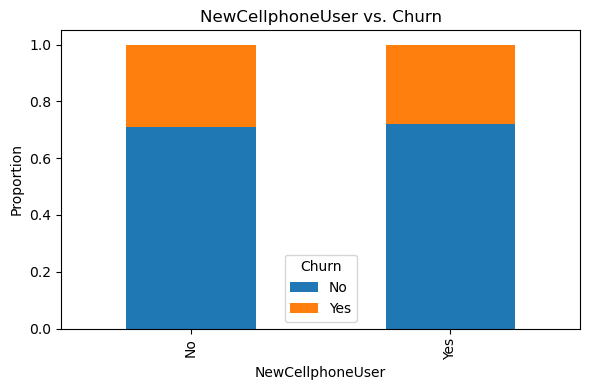

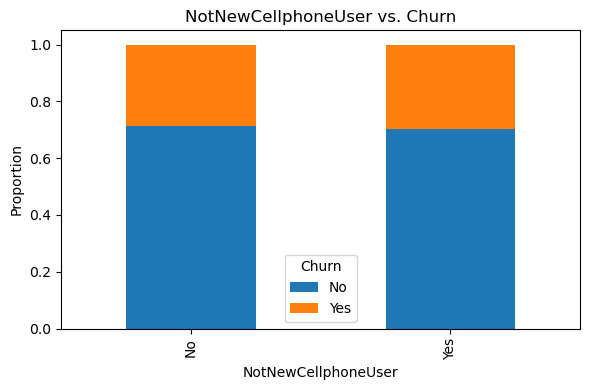

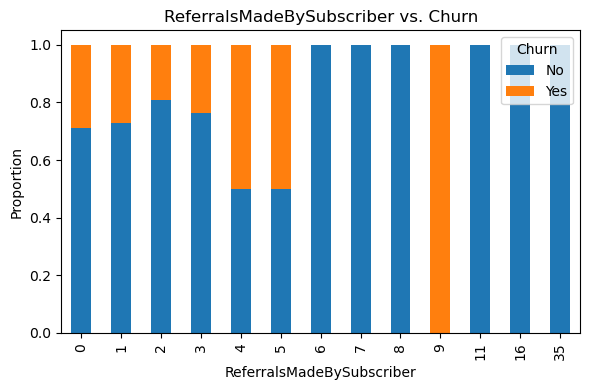

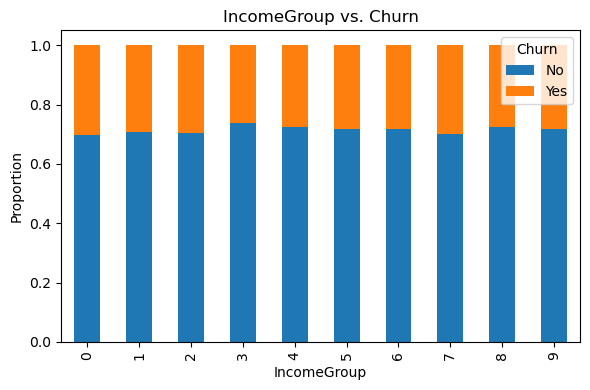

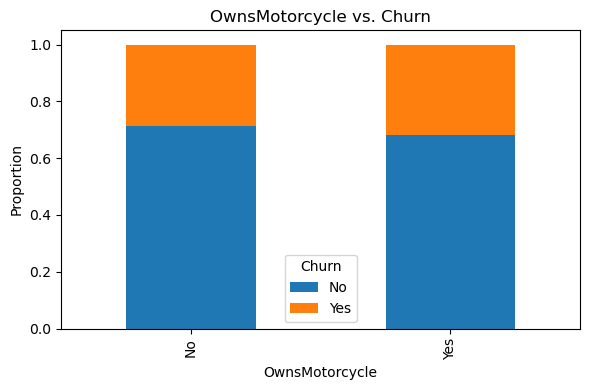

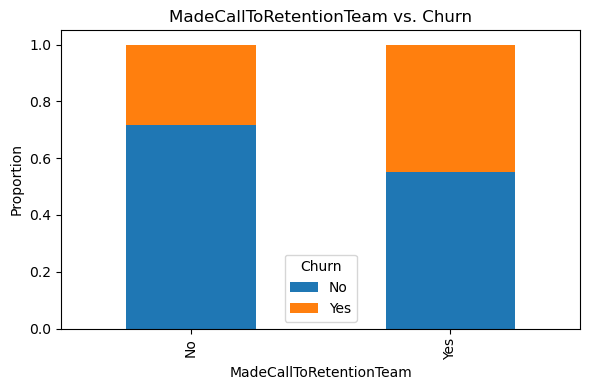

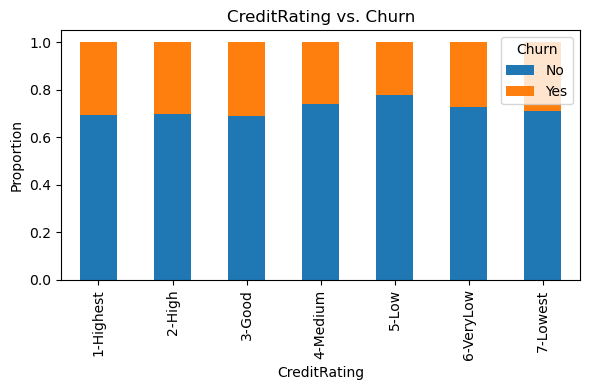

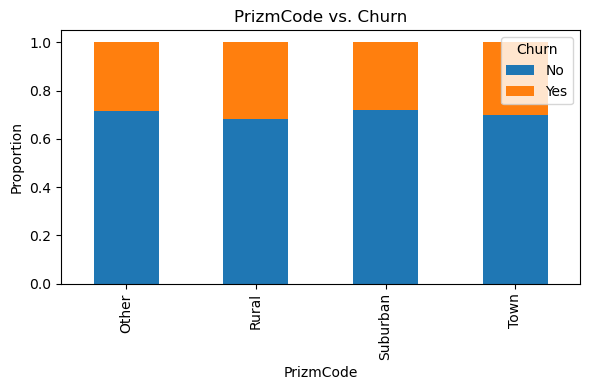

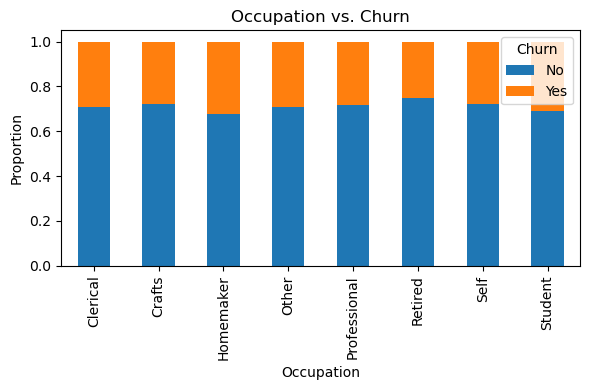

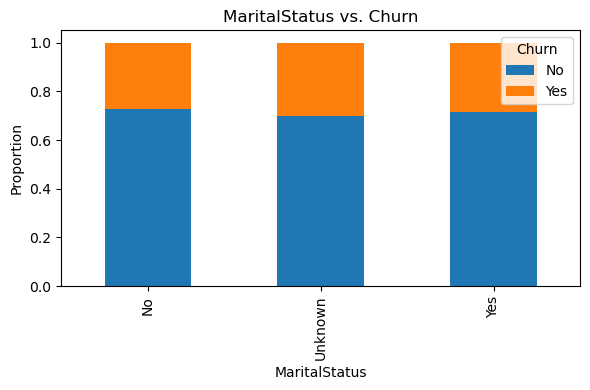

In [30]:
# Exclude the high-cardinality feature from visualization.
plot_categorical_features = [
    col for col in categorical_predictors
    if col != "ServiceArea"
]

# Visualize the relationship between categorical predictors and customer churn.
for col in plot_categorical_features:
    (
        pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        )
        .plot(
            kind="bar",
            stacked=True,
            figsize=(6, 4)
        )
    )

    plt.title(f"{col} vs. Churn")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

### Chi-Square Test for Categorical Features

In [31]:
# Evaluate the association between categorical predictors and churn using the Chi-square test.
chi_results = []

for col in categorical_predictors:
    contingency_table = pd.crosstab(df[col], df["Churn"])

    chi2, p_value, _, _ = chi2_contingency(contingency_table)

    chi_results.append({
        "Feature": col,
        "Chi-square Statistic": round(chi2, 2),
        "P-value": round(p_value, 4),
        "Selected": p_value < 0.05
    })

chi_results = (
    pd.DataFrame(chi_results)
    .sort_values(by="P-value")
    .reset_index(drop=True)
)

selected_categorical_features = chi_results.loc[
    chi_results["Selected"],
    "Feature"
].tolist()

chi_results

,Feature,Chi-square Statistic,P-value,Selected
0,ServiceArea,959.28,0.0000,True
1,CreditRating,213.79,0.0000,True
2,MadeCallToRetentionTeam,230.31,0.0000,True
3,RespondsToMailOffers,26.65,0.0000,True
4,BuysViaMailOrder,23.97,0.0000,True
5,MaritalStatus,37.00,0.0000,True
6,HandsetWebCapable,197.76,0.0000,True
7,HandsetRefurbished,45.18,0.0000,True
8,HandsetModels,101.24,0.0000,True
9,IncomeGroup,32.73,0.0001,True


### Insights

- Thirteen of the 24 categorical predictors were significantly associated with customer churn (p < 0.05).
- These statistically significant predictors were retained as candidate features for subsequent feature selection and model development.
- The Chi-square test served as an initial screening method to identify potential associations and does not imply a causal relationship with customer churn.

### Numerical Feature Analysis

In [32]:
# Check the number of unique values in each numerical feature.
numerical_unique_summary = (
    df[numerical_features]
    .nunique()
    .sort_values()
    .rename("Unique Values")
    .to_frame()
)

numerical_unique_summary

,Unique Values
RetentionOffersAccepted,4
RetentionCalls,5
ActiveSubs,12
AdjustmentsToCreditRating,15
UniqueSubs,15
Handsets,23
CallForwardingCalls,31
AgeHH2,43
AgeHH1,43
MonthsInService,56


In [33]:
# Display summary statistics for numerical features.
numerical_summary = (
    df[numerical_features]
    .describe()
    .T
    .round(2)
)

numerical_summary

,count,mean,std,min,25%,50%,75%,max
MonthlyRevenue,50866.0,58.83,44.51,-6.17,33.61,48.46,71.06,1223.38
MonthlyMinutes,50866.0,525.61,529.87,0.00,158.00,366.00,723.00,7359.00
TotalRecurringCharge,50866.0,46.83,23.85,-11.00,30.00,45.00,60.00,400.00
DirectorAssistedCalls,50866.0,0.90,2.23,0.00,0.00,0.25,0.99,159.39
OverageMinutes,50866.0,40.02,96.60,0.00,0.00,3.00,41.00,4321.00
RoamingCalls,50866.0,1.24,9.82,0.00,0.00,0.00,0.30,1112.40
PercChangeMinutes,50655.0,-11.58,257.53,-3875.00,-83.00,-5.00,66.00,5192.00
PercChangeRevenues,50655.0,-1.20,39.57,-1107.70,-7.10,-0.30,1.60,2483.50
DroppedCalls,51022.0,6.01,9.04,0.00,0.70,3.00,7.70,221.70
BlockedCalls,51022.0,4.08,10.95,0.00,0.00,1.00,3.70,384.30


In [34]:
# Summarize the number and proportion of zero values in each numerical feature.
zero_summary = (
    pd.DataFrame({
        "Zero Count": (df[numerical_features] == 0).sum(),
        "Zero Ratio (%)": (
            (df[numerical_features] == 0).mean() * 100
        ).round(2)
    })
    .sort_values(by="Zero Ratio (%)", ascending=False)
)

zero_summary

,Zero Count,Zero Ratio (%)
CallForwardingCalls,50788,99.54
RetentionOffersAccepted,50142,98.28
RetentionCalls,49278,96.58
AdjustmentsToCreditRating,49184,96.40
ThreewayCalls,37119,72.75
RoamingCalls,34928,68.46
CustomerCareCalls,28006,54.89
AgeHH2,26078,51.11
CallWaitingCalls,25019,49.04
DirectorAssistedCalls,24503,48.02


### Numerical Features with High Proportions of Zero Values

In [35]:
# Identify numerical features with more than 95% zero values.
# These features are analyzed separately because their distributions are highly dominated by zeros.

high_zero_features = [
    "CallForwardingCalls",
    "RetentionCalls",
    "RetentionOffersAccepted",
    "AdjustmentsToCreditRating"
]

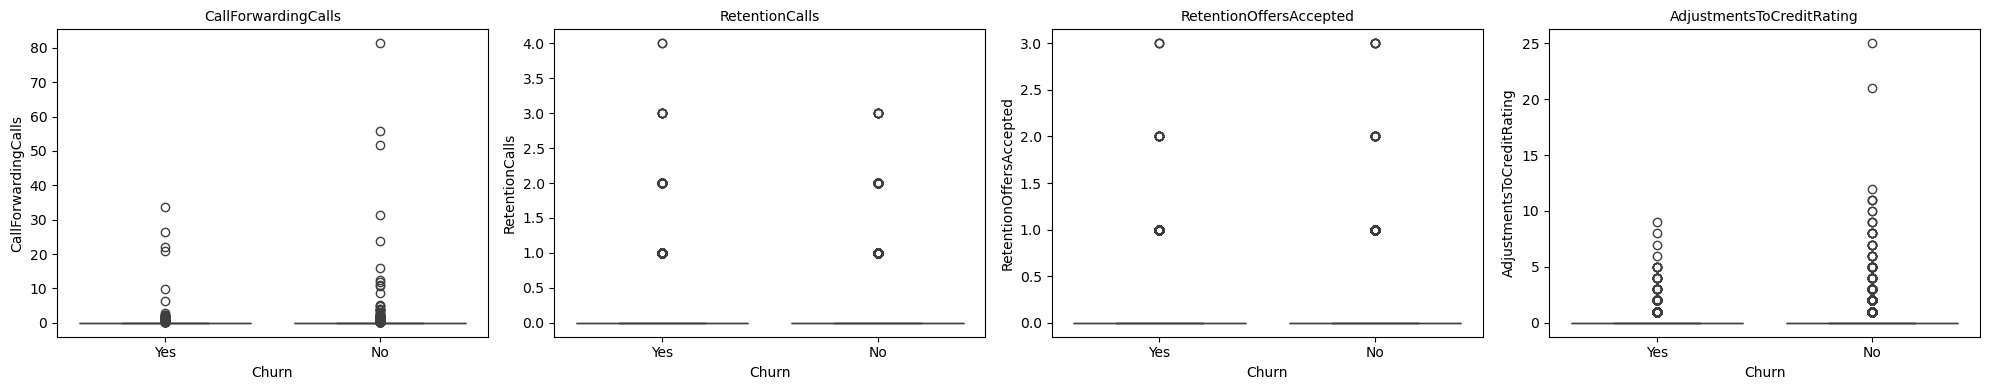

In [36]:
# Compare the distributions of high-zero numerical features by churn status.
n_features = len(high_zero_features)

plt.figure(figsize=(5 * n_features, 4))

for i, col in enumerate(high_zero_features, 1):
    plt.subplot(1, n_features, i)

    sns.boxplot(
        data=df,
        x="Churn",
        y=col
    )

    plt.title(col, fontsize=10)
    plt.xlabel("Churn")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [37]:
# Evaluate high-zero numerical features using the Kruskal-Wallis test.
kruskal_results = []

for col in high_zero_features:

    groups = [
        df.loc[df["Churn"] == churn_status, col].dropna()
        for churn_status in df["Churn"].unique()
    ]

    statistic, p_value = kruskal(*groups)

    kruskal_results.append({
        "Feature": col,
        "Kruskal-Wallis Statistic": round(statistic, 2),
        "P-value": round(p_value, 4),
        "Selected": p_value < 0.05
    })

kruskal_results = (
    pd.DataFrame(kruskal_results)
    .sort_values(by="P-value")
    .reset_index(drop=True)
)

kruskal_results

,Feature,Kruskal-Wallis Statistic,P-value,Selected
0,RetentionCalls,231.15,0.0000,True
1,RetentionOffersAccepted,65.15,0.0000,True
2,AdjustmentsToCreditRating,12.69,0.0004,True
3,CallForwardingCalls,1.15,0.2828,False


In [38]:
# Remove CallForwardingCalls because it is not significantly associated with customer churn
# based on the Kruskal-Wallis test (p > 0.05).
df = df.drop(columns="CallForwardingCalls")

# Update the numerical feature list after removing the feature.
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

### Distribution of Numerical Features

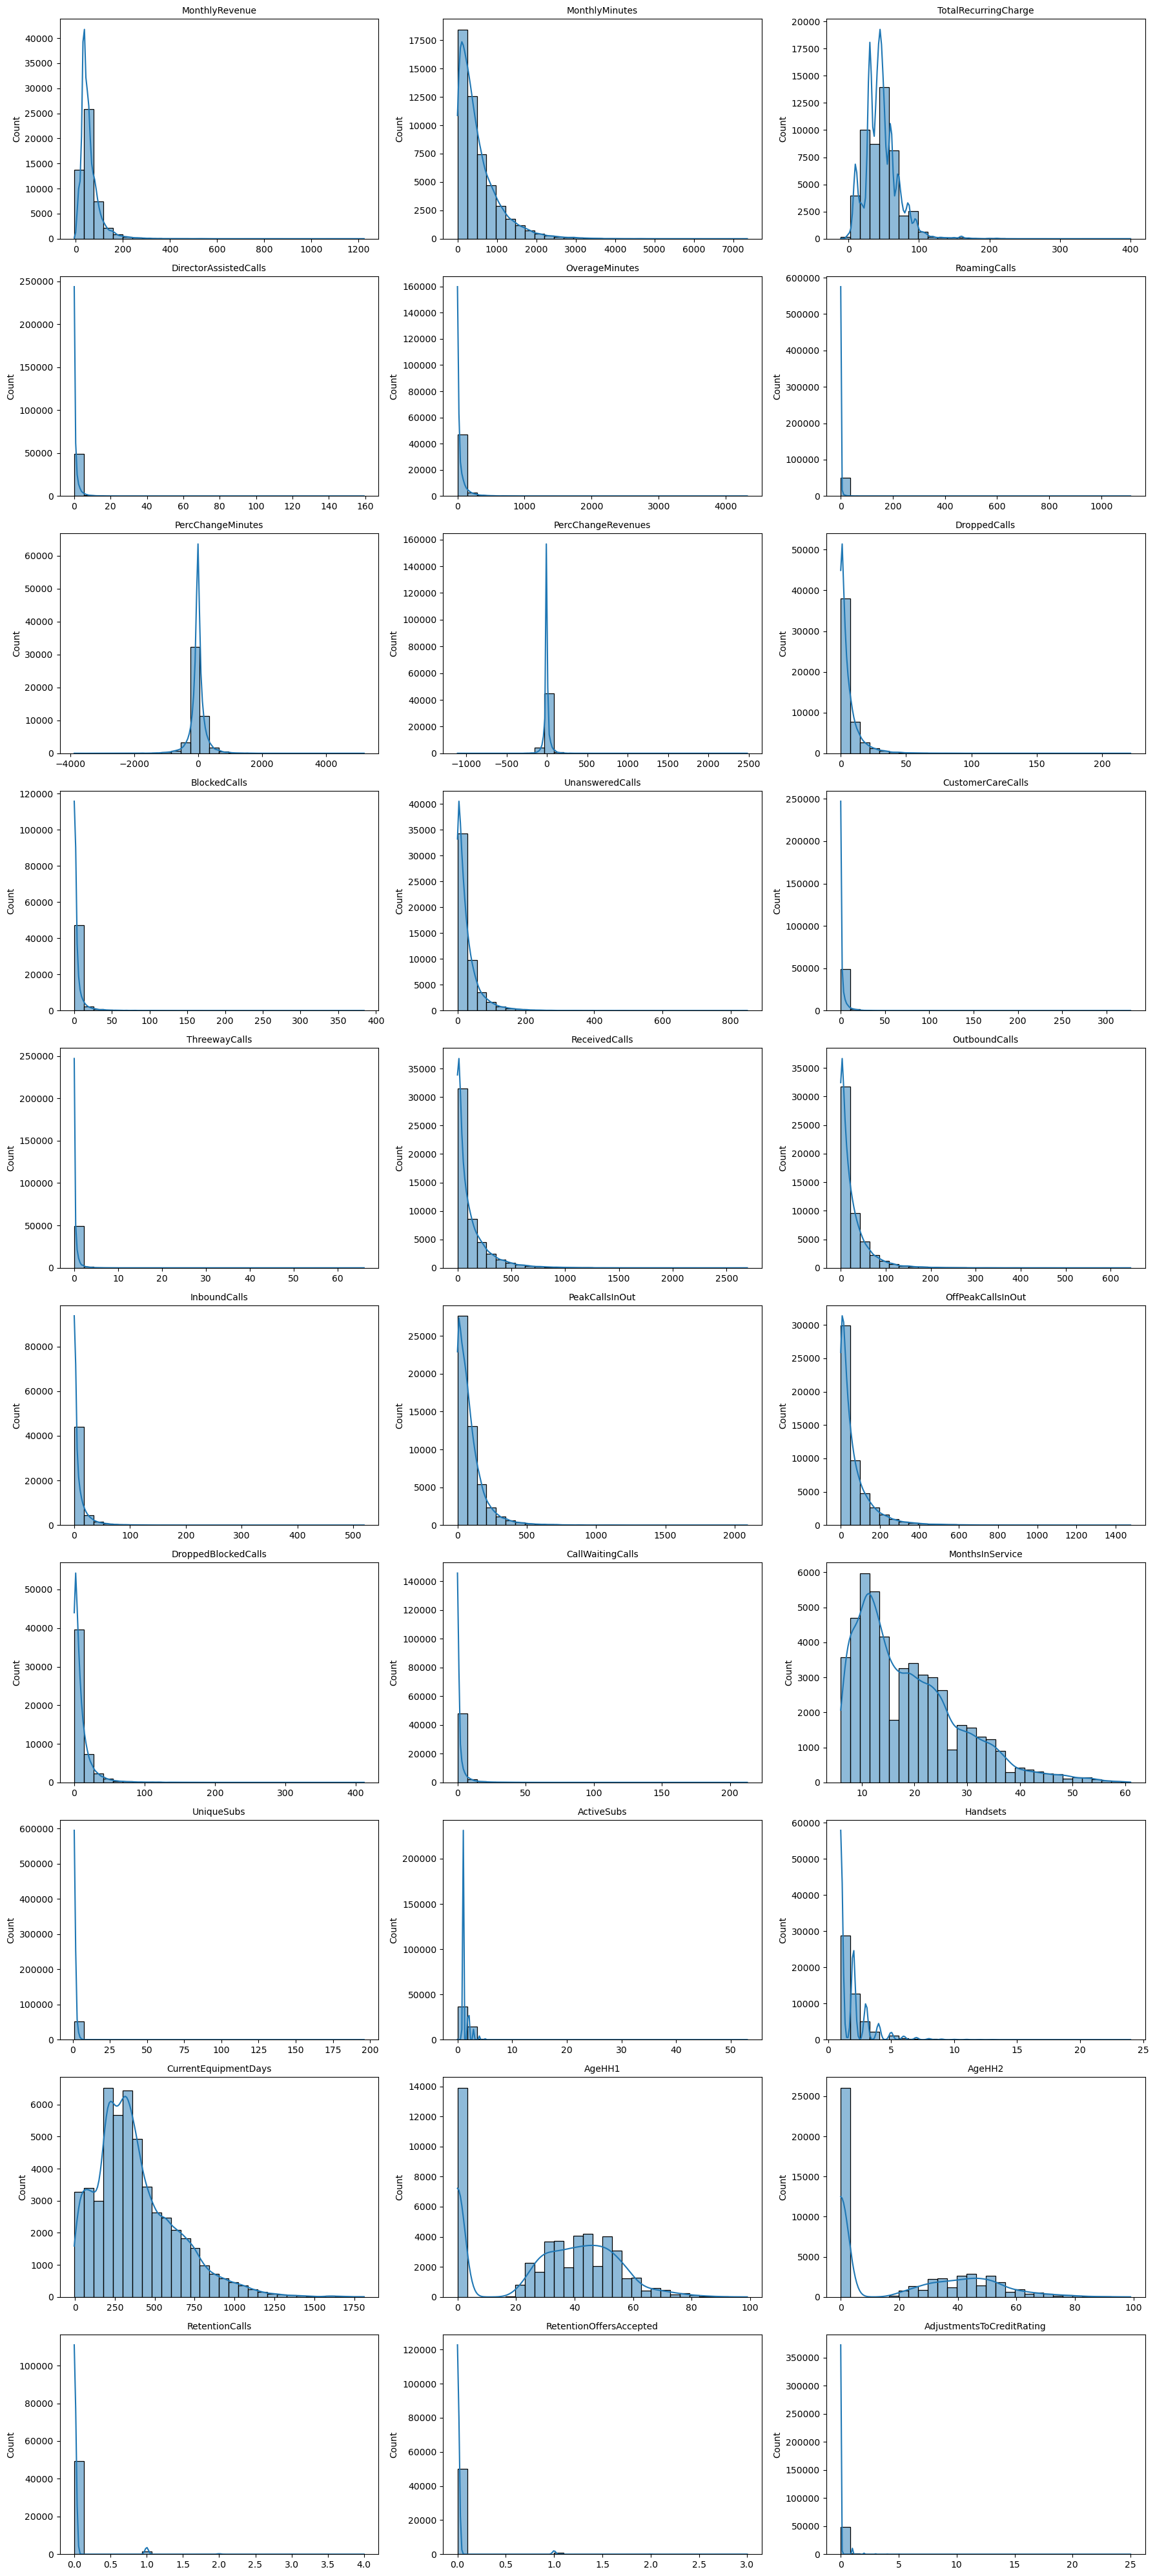

In [39]:
# Visualize the distribution of numerical features.

n_cols = 3
n_rows = int(np.ceil(len(numerical_features) / n_cols))

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30
    )

    plt.title(col, fontsize=10)
    plt.xlabel("")

plt.tight_layout()
plt.show()

### Outlier Analysis

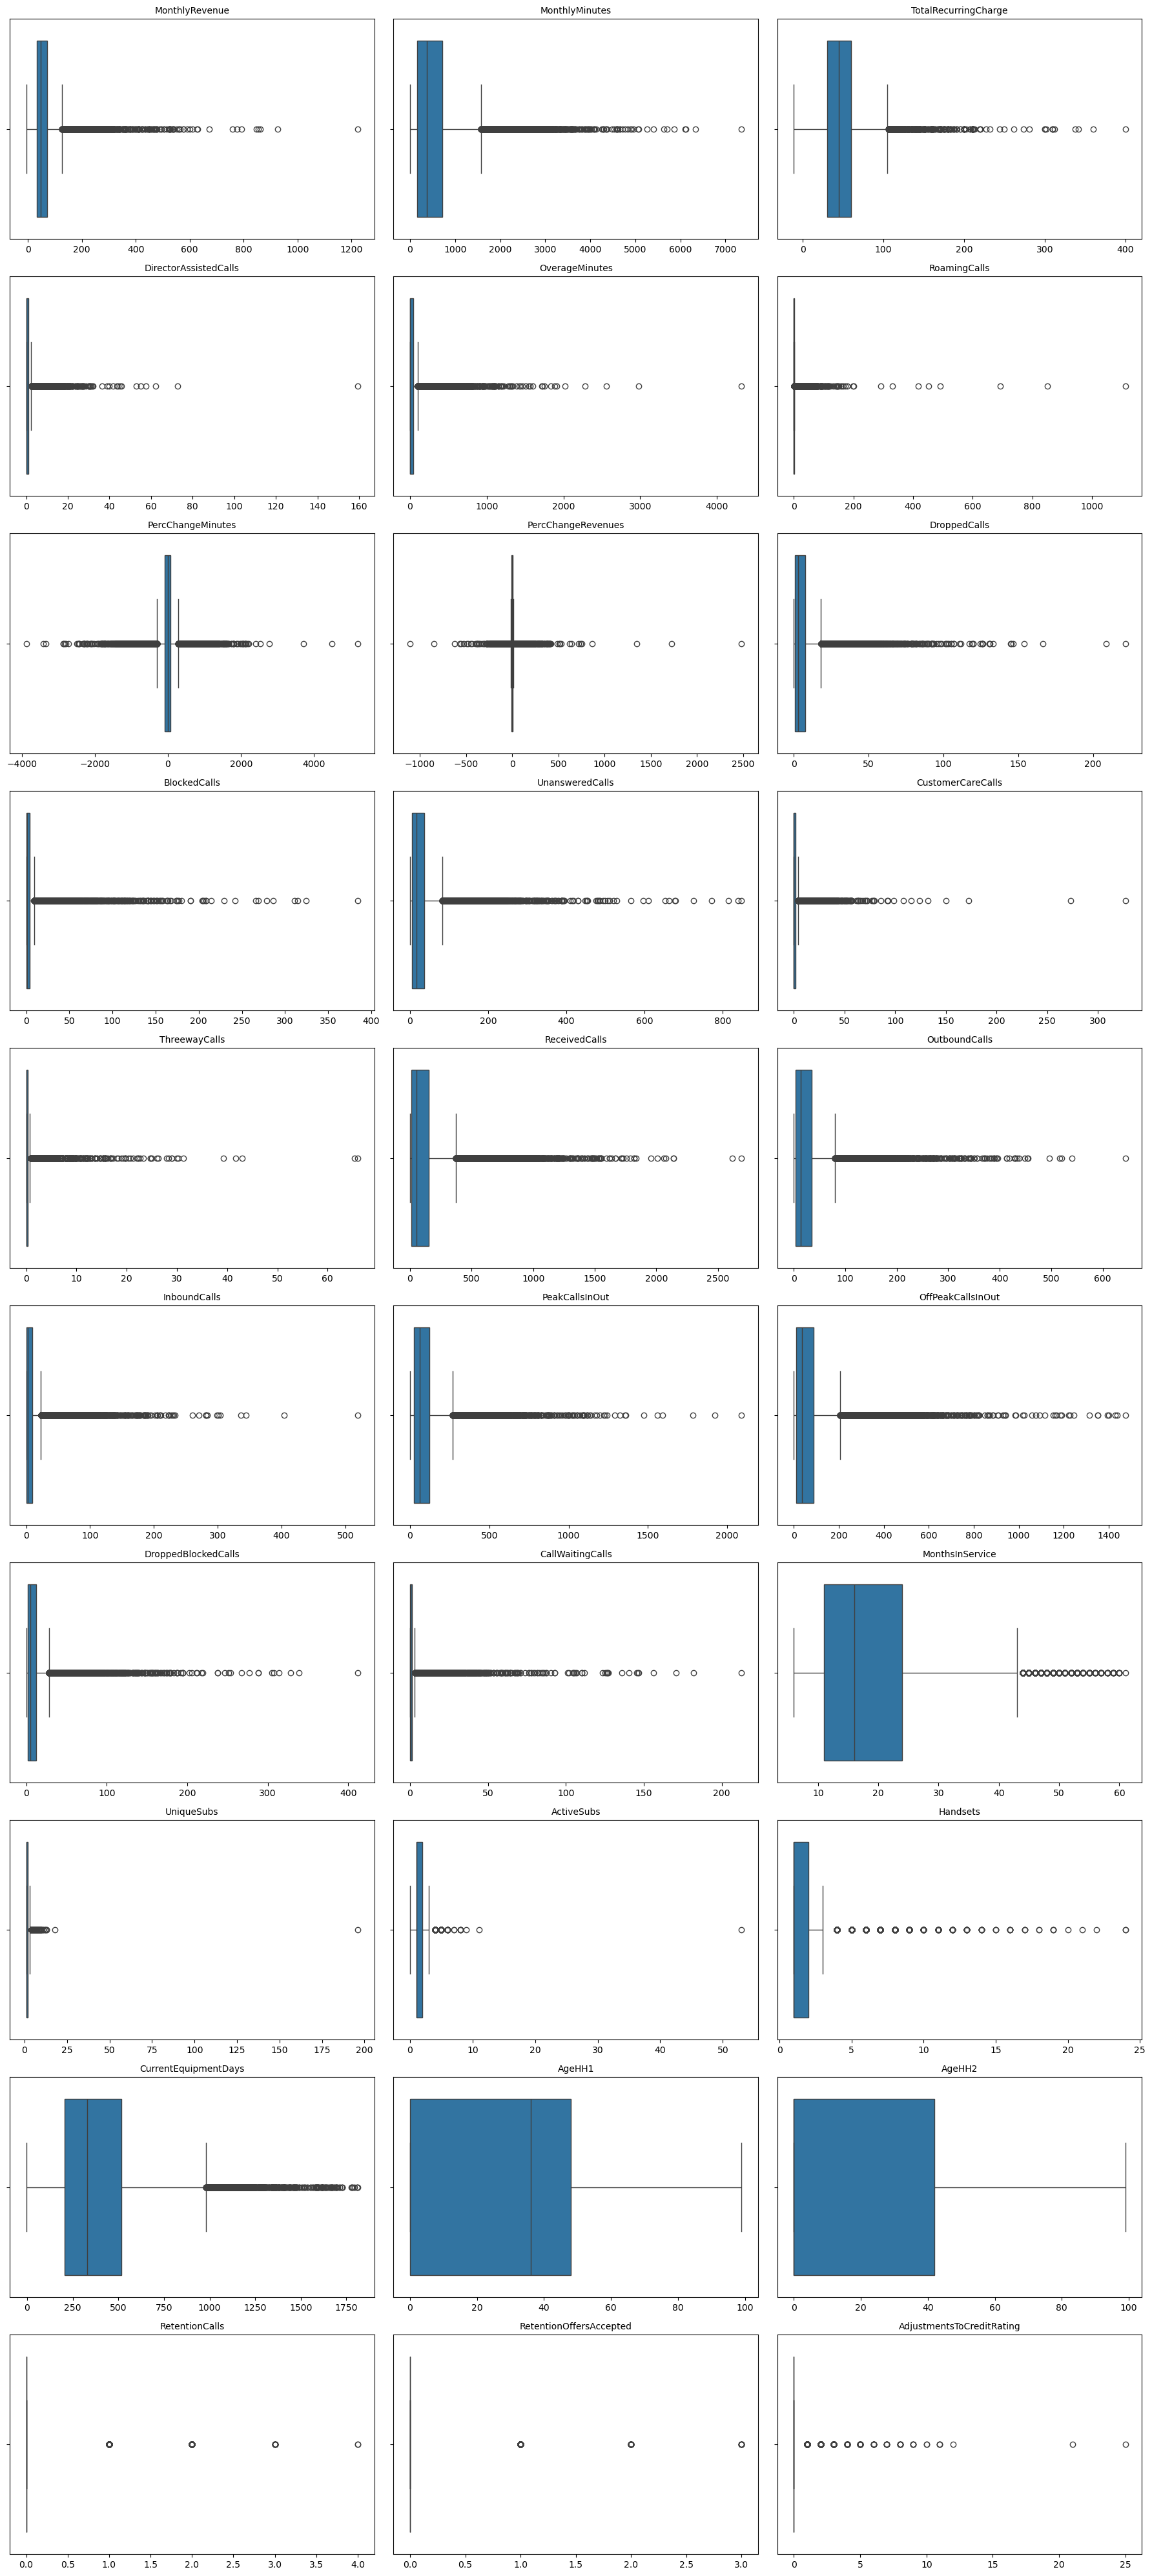

In [40]:
# Visualize potential outliers in numerical features.
n_cols = 3
n_rows = int(np.ceil(len(numerical_features) / n_cols))

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(
        data=df,
        x=col
    )

    plt.title(col, fontsize=10)
    plt.xlabel("")

plt.tight_layout()
plt.show()

### Missing Value Analysis

In [41]:
# Summarize missing values in numerical features.
numerical_missing = (
    pd.DataFrame({
        "Missing Count": df[numerical_features].isna().sum(),
        "Missing Ratio (%)": (
            df[numerical_features].isna().mean() * 100
        ).round(2)
    })
    .query("`Missing Count` > 0")
    .sort_values(by="Missing Ratio (%)", ascending=False)
)

numerical_missing

,Missing Count,Missing Ratio (%)
AgeHH1,909,1.78
AgeHH2,909,1.78
PercChangeMinutes,367,0.72
PercChangeRevenues,367,0.72
MonthlyRevenue,156,0.31
MonthlyMinutes,156,0.31
TotalRecurringCharge,156,0.31
DirectorAssistedCalls,156,0.31
OverageMinutes,156,0.31
RoamingCalls,156,0.31


### Distribution Shape Analysis

In [42]:
# Summarize the distribution shape of numerical features using skewness and kurtosis.
distribution_summary = (
    pd.DataFrame({
        "Skewness": df[numerical_features].skew(),
        "Kurtosis": df[numerical_features].kurtosis()
    })
    .round(2)
    .sort_values(by="Skewness", key=lambda x: x.abs(), ascending=False)
)

distribution_summary

,Skewness,Kurtosis
UniqueSubs,79.68,12517.92
RoamingCalls,57.87,5147.88
AdjustmentsToCreditRating,18.62,704.03
ThreewayCalls,17.55,603.98
CustomerCareCalls,14.27,581.51
DirectorAssistedCalls,13.58,599.72
CallWaitingCalls,11.12,218.79
ActiveSubs,10.66,676.69
BlockedCalls,9.80,168.46
RetentionOffersAccepted,8.70,90.57


### Insights

- Several numerical features exhibit substantial positive skewness and high kurtosis.
- These distribution characteristics indicate that many variables are non-normally distributed and contain potential outliers.
- Since the final model is based on Random Forest, these non-normal distributions are unlikely to substantially affect model performance, and no transformation was applied at this stage.

## Correlation Analysis

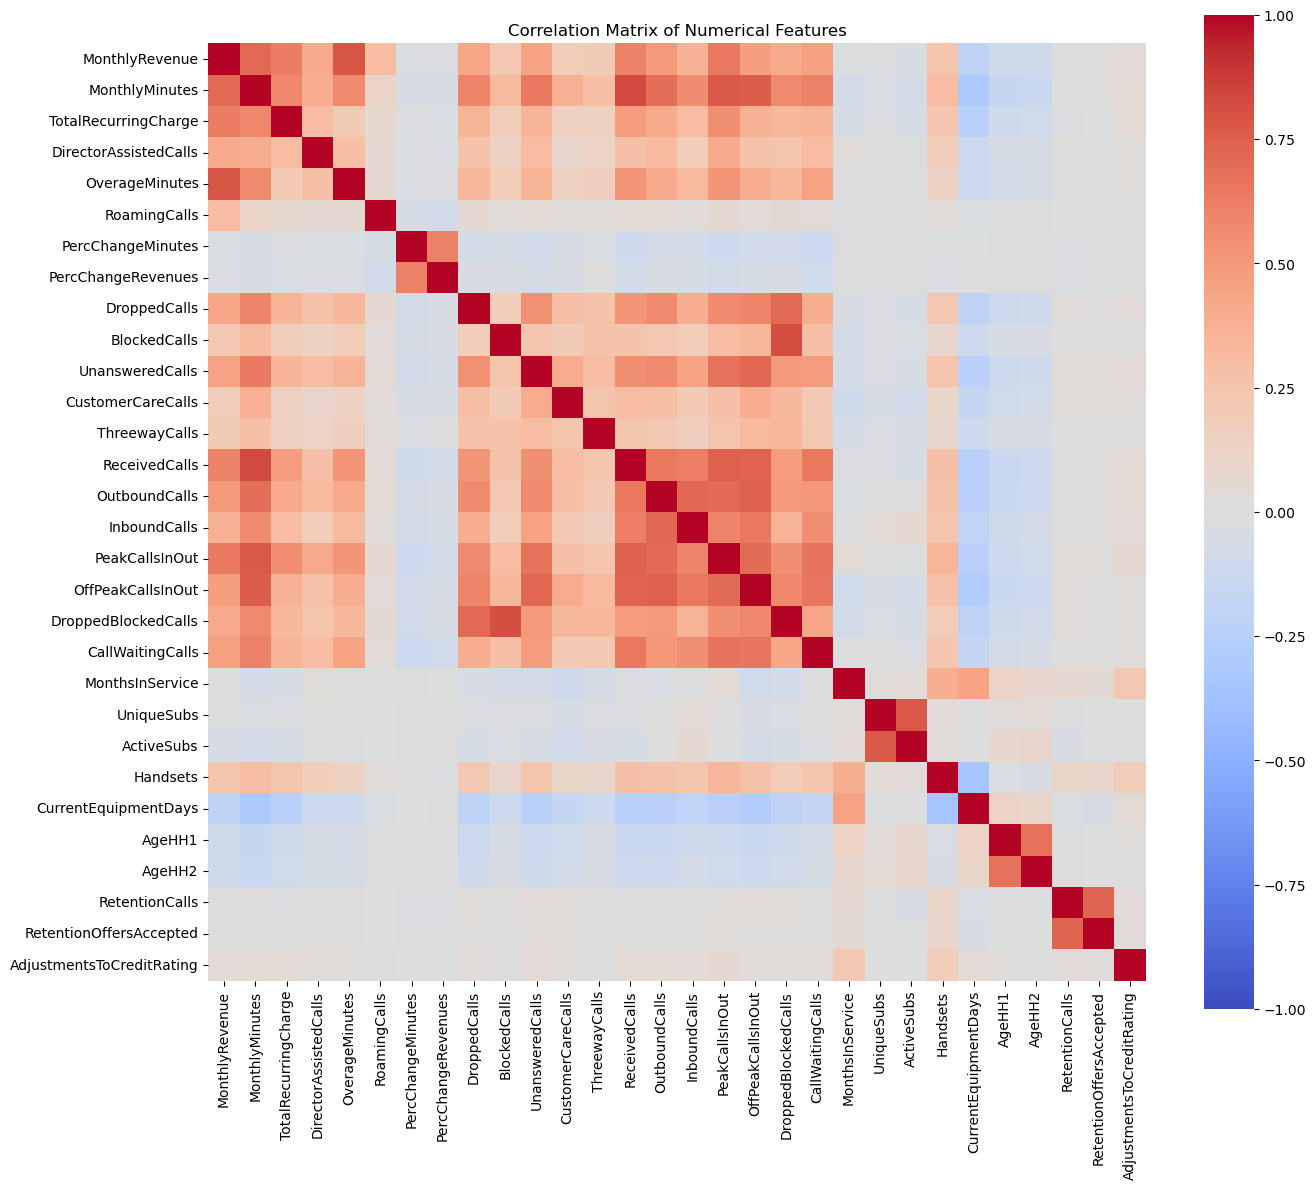

In [43]:
# Compute and visualize the correlation matrix for numerical features.
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(14, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [44]:
# Identify highly correlated numerical feature pairs.
correlation_threshold = 0.80

high_corr_pairs = (
    correlation_matrix
    .abs()
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .rename("Correlation")
    .reset_index()
)

high_corr_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

high_corr_pairs = (
    high_corr_pairs
    .query("Correlation >= @correlation_threshold")
    .sort_values(by="Correlation", ascending=False)
    .reset_index(drop=True)
)

high_corr_pairs

,Feature 1,Feature 2,Correlation
0,MonthlyMinutes,ReceivedCalls,0.828878
1,BlockedCalls,DroppedBlockedCalls,0.816266


In [45]:
# Remove highly correlated features to reduce redundancy.
correlated_features_to_remove = [
    "MonthlyMinutes",
    "BlockedCalls"
]

df = df.drop(columns=correlated_features_to_remove)

# Update the numerical feature list after removing the selected features.
numerical_features = (
    df.select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

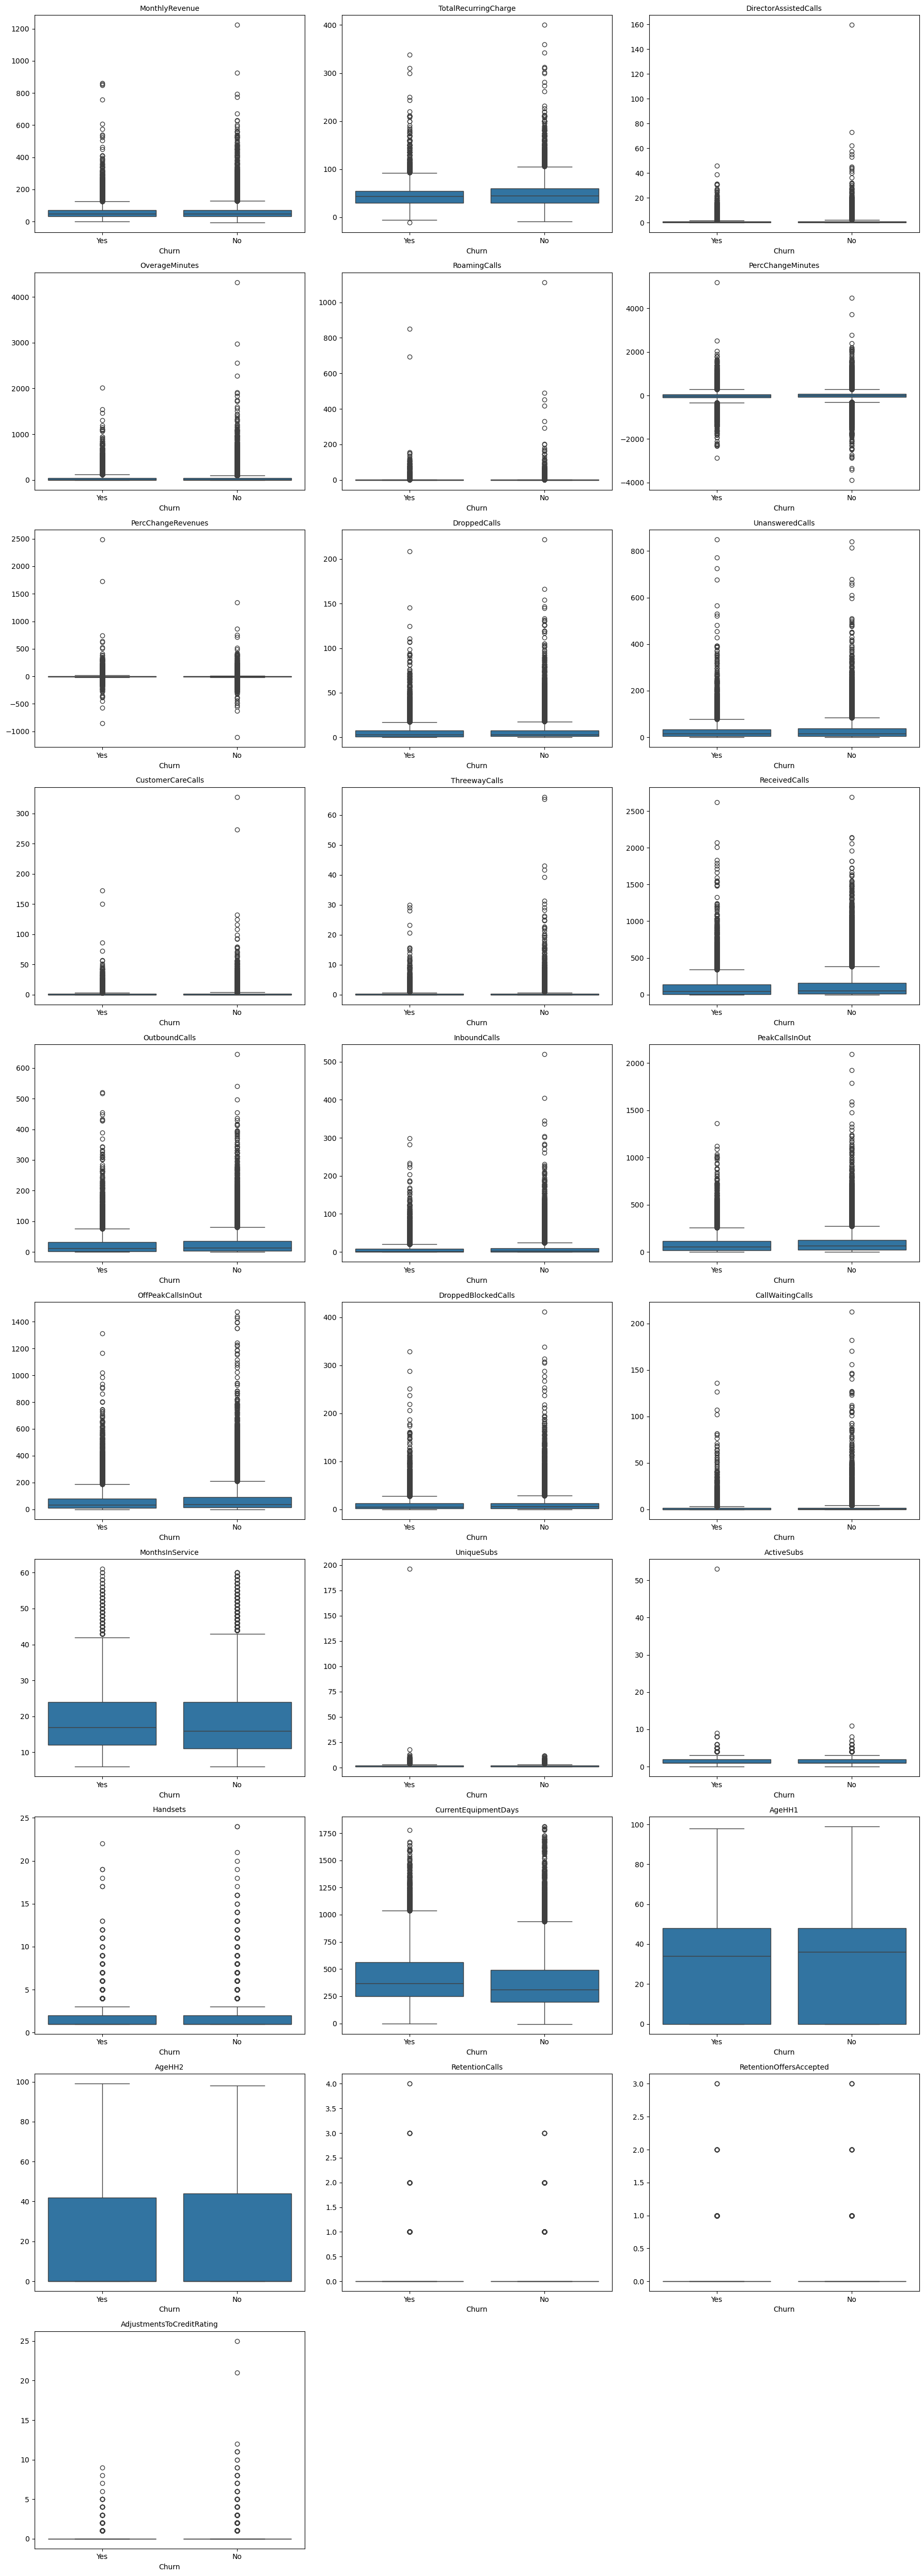

In [46]:
# Compare the distribution of numerical features by churn status.

n_cols = 3
n_rows = int(np.ceil(len(numerical_features) / n_cols))

plt.figure(figsize=(18, 5 * n_rows))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(
        data=df,
        x="Churn",
        y=col
    )

    plt.title(col, fontsize=10)
    plt.xlabel("Churn")
    plt.ylabel("")

plt.tight_layout()
plt.show()

### Kruskal-Wallis Test for Numerical Features

In [47]:
# Evaluate the association between numerical features and customer churn
# using the Kruskal-Wallis test.
kruskal_results = []

for col in numerical_features:

    groups = [
        df.loc[df["Churn"] == churn_status, col].dropna()
        for churn_status in df["Churn"].unique()
    ]

    statistic, p_value = kruskal(*groups)

    kruskal_results.append({
        "Feature": col,
        "Kruskal-Wallis Statistic": round(statistic, 2),
        "P-value": round(p_value, 4),
        "Selected": p_value < 0.05
    })

kruskal_results = (
    pd.DataFrame(kruskal_results)
    .sort_values(by="P-value")
    .reset_index(drop=True)
)

selected_numerical_features = kruskal_results.loc[
    kruskal_results["Selected"],
    "Feature"
].tolist()

kruskal_results

,Feature,Kruskal-Wallis Statistic,P-value,Selected
0,MonthlyRevenue,28.55,0.0000,True
1,RetentionCalls,231.15,0.0000,True
2,AgeHH1,48.97,0.0000,True
3,CurrentEquipmentDays,697.09,0.0000,True
4,Handsets,66.75,0.0000,True
5,ActiveSubs,25.65,0.0000,True
6,UniqueSubs,103.09,0.0000,True
7,MonthsInService,80.14,0.0000,True
8,CallWaitingCalls,73.38,0.0000,True
9,DroppedBlockedCalls,40.37,0.0000,True


### Insights

- One high-zero numerical feature, **CallForwardingCalls**, was removed because it showed no statistically significant association with customer churn.
- Two highly correlated numerical features, **MonthlyMinutes** and **BlockedCalls**, were removed to reduce feature redundancy and potential multicollinearity.
- Twenty-six of the 28 numerical features showed statistically significant differences between churn and non-churn customers based on the Kruskal-Wallis test (p < 0.05).
- The statistically significant numerical features were retained as candidate features for subsequent model development.

## Feature Selection

To improve model performance and interpretability, features were selected based on statistical significance and correlation analysis. Variables that were not significantly associated with customer churn or that provided redundant information were excluded before model development.

In [48]:
# Combine statistically selected categorical and numerical features.
selected_features = (
    selected_categorical_features +
    selected_numerical_features
)

# Create the final dataset for modeling.
df_fs = df[selected_features].copy()

# Add the target variable.
df_fs["Churn"] = df["Churn"]

df_fs.head(2)

,ServiceArea,CreditRating,MadeCallToRetentionTeam,RespondsToMailOffers,BuysViaMailOrder,MaritalStatus,HandsetWebCapable,HandsetRefurbished,HandsetModels,IncomeGroup,...,UnansweredCalls,DroppedCalls,PercChangeMinutes,OverageMinutes,DirectorAssistedCalls,TotalRecurringCharge,OutboundCalls,AgeHH2,AdjustmentsToCreditRating,Churn
0,SEAPOR503,1-Highest,Yes,Yes,Yes,No,Yes,No,2.0,4,...,6.3,0.7,-157.0,0.0,0.25,22.0,0.0,0.0,0,Yes
1,PITHOM412,4-Medium,No,Yes,Yes,Yes,No,No,1.0,5,...,2.7,0.3,-4.0,0.0,0.00,17.0,0.0,42.0,0,Yes


In [49]:
# Summarize the final predictor set.

final_categorical_features = [
    col for col in df_fs.select_dtypes(include="object").columns
    if col != "Churn"
]

final_numerical_features = (
    df_fs.select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

print(f"Categorical features: {len(final_categorical_features)}")
print(f"Numerical features: {len(final_numerical_features)}")
print(f"Total predictor features: {len(final_categorical_features) + len(final_numerical_features)}")

Categorical features: 14
Numerical features: 26
Total predictor features: 40


### Target Variable Encoding

In [50]:
# Encode the target variable.
df_fs["Churn"] = df_fs["Churn"].map({
    "No": 0,
    "Yes": 1
})

df_fs["Churn"].value_counts()

Churn
0    36323
1    14699
Name: count, dtype: int64

In [51]:
# Separate predictors and target.
X = df_fs.drop(columns="Churn")
y = df_fs["Churn"]

print(f"Predictor matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

print("\nTarget distribution:")
print(y.value_counts())

Predictor matrix shape: (51022, 40)
Target vector shape: (51022,)

Target distribution:
Churn
0    36323
1    14699
Name: count, dtype: int64


### Categorical Encoding

In [52]:
# Remove high-cardinality feature before one-hot encoding.
X = X.drop(columns="ServiceArea", errors="ignore")

# Apply one-hot encoding to categorical features.
X = pd.get_dummies(X)

print(f"Number of features after encoding: {X.shape[1]}")

X.head(2)

Number of features after encoding: 79


,MonthlyRevenue,RetentionCalls,AgeHH1,CurrentEquipmentDays,Handsets,ActiveSubs,UniqueSubs,MonthsInService,CallWaitingCalls,DroppedBlockedCalls,...,PrizmCode_Other,PrizmCode_Rural,PrizmCode_Suburban,PrizmCode_Town,Homeownership_Known,Homeownership_Unknown,ChildrenInHH_No,ChildrenInHH_Yes,HasCreditCard_No,HasCreditCard_Yes
0,24.00,1,62.0,361.0,2.0,1,2,61,0.3,1.3,...,False,False,True,False,True,False,True,False,False,True
1,16.99,0,40.0,1504.0,2.0,1,1,58,0.0,0.3,...,False,False,True,False,True,False,False,True,False,True


### Insights

- The high-cardinality feature **ServiceArea** was excluded before one-hot encoding to prevent a substantial increase in the number of encoded features.
- Categorical features were transformed into binary indicators using one-hot encoding to make them suitable for machine learning models.
- All categories were retained during one-hot encoding because tree-based models are not sensitive to dummy-variable multicollinearity.
- The encoded feature matrix was used as the input for subsequent model development.

### Train/Test Split

In [53]:
# Split the data into training and validation sets using stratified sampling.
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=1234
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_valid.shape}")

Training set: (38266, 79)
Validation set: (12756, 79)


In [54]:
# Impute missing numerical values using KNNImputer.
# The imputer is fitted on the training set only to prevent data leakage.

imputer = KNNImputer(n_neighbors=3)

X_train[final_numerical_features] = imputer.fit_transform(
    X_train[final_numerical_features]
)

X_valid[final_numerical_features] = imputer.transform(
    X_valid[final_numerical_features]
)

print(f"Remaining missing values (train): {X_train.isna().sum().sum()}")
print(f"Remaining missing values (validation): {X_valid.isna().sum().sum()}")

Remaining missing values (train): 0
Remaining missing values (validation): 0


In [55]:
# Apply SMOTE to balance the training data.
smote = SMOTE(random_state=1234)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

print(f"Training set before SMOTE: {X_train.shape}")
print(f"Training set after SMOTE: {X_train_resampled.shape}")

Training set before SMOTE: (38266, 79)
Training set after SMOTE: (54484, 79)


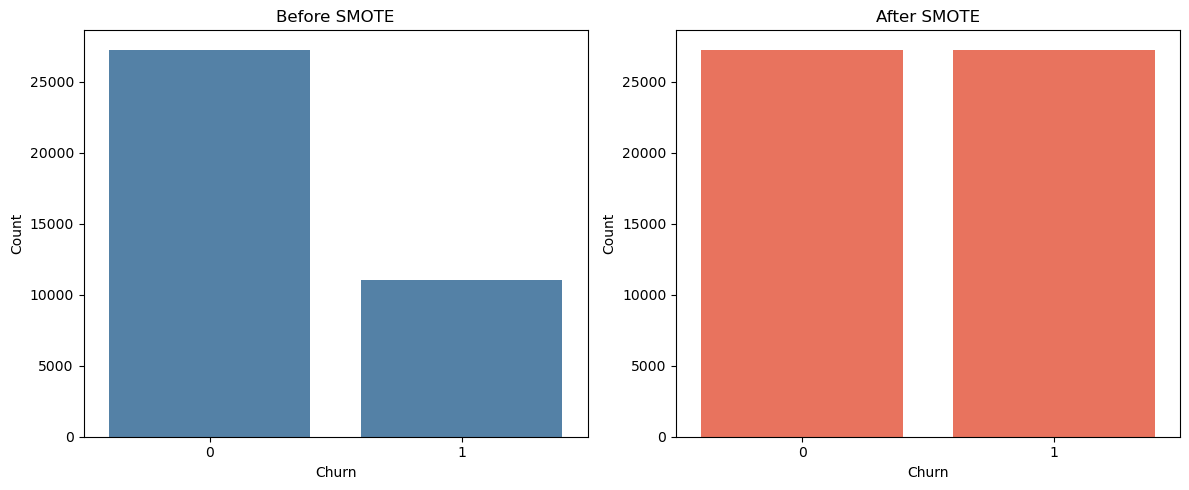

Class distribution before SMOTE:
Churn
0    27242
1    11024
Name: count, dtype: int64

Class distribution after SMOTE:
Churn
0    27242
1    27242
Name: count, dtype: int64


In [56]:
# Compare the class distribution before and after SMOTE.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0], color="steelblue")
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")

sns.countplot(x=y_train_resampled, ax=axes[1], color="tomato")
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Class distribution before SMOTE:")
print(y_train.value_counts())

print("\nClass distribution after SMOTE:")
print(y_train_resampled.value_counts())

### Insights

- The dataset was split into training (38,266 samples) and validation (12,756 samples) sets using stratified sampling to preserve the original class distribution.
- Missing numerical values were imputed using KNNImputer after the train-test split. All missing values were successfully removed from both the training and validation sets.
- SMOTE was applied only to the training set, increasing its size from 38,266 to 54,484 samples while leaving the validation set unchanged.
- After SMOTE, the training data became approximately balanced across the two churn classes, enabling the model to better learn patterns associated with churn.

## Data Preparation Summary

### Feature Engineering

- Selected informative features using statistical tests:
  - Chi-square test for categorical features
  - Kruskal-Wallis test for numerical features
  - Correlation analysis to remove highly redundant numerical features
- Encoded the target variable by mapping **No → 0** and **Yes → 1**.
- Applied one-hot encoding to categorical features while retaining all categories.
- Excluded the `ServiceArea` feature because its high cardinality would substantially increase the dimensionality of the encoded feature space.
- Imputed missing numerical values using KNNImputer after the train-test split to prevent data leakage.
- Applied SMOTE only to the training set to address class imbalance.

### Final Dataset

- Encoded feature matrix: **79 features**
- Training set:
  - Original: **38,266 samples**
  - After SMOTE: **54,484 samples**
- Validation set:
  - **12,756 samples**

## Model Development

We compare five Random Forest-based models to evaluate how class imbalance handling and hyperparameter tuning affect churn prediction performance.

1. Baseline Random Forest
2. Random Forest with Class Weight
3. Random Forest with Randomized Search
4. Random Forest with SMOTE
5. Random Forest with SMOTE + Randomized Search

In [57]:
# Configure model training settings.
CV_FOLDS = 3
N_JOBS = -1
N_RANDOM_SEARCH = 40

# Store evaluation results for model comparison.
model_results = []

In [58]:
def evaluate_model(model, X_train_data, y_train_data, X_valid, y_valid, model_name):
    # Train the model.
    model.fit(X_train_data, y_train_data)

    # Generate class predictions and predicted probabilities.
    y_pred = model.predict(X_valid)
    y_prob = model.predict_proba(X_valid)[:, 1]

    # Calculate evaluation metrics.
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_valid,
        y_pred,
        average="binary"
    )

    roc_auc = roc_auc_score(y_valid, y_prob)

    # Store results for model comparison.
    model_results.append({
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    # Print model performance.
    print(f"Model: {model_name}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    return model, y_prob

### 1. Baseline Random Forest

In [59]:
# Train the baseline Random Forest model.
baseline_model = RandomForestClassifier(random_state=1234)

baseline_rf, baseline_prob = evaluate_model(
    baseline_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Baseline Random Forest"
)

Model: Baseline Random Forest
Precision: 0.5190
Recall: 0.0631
F1 Score: 0.1126
ROC-AUC: 0.6502


### 2. Random Forest with class weight

In [60]:
# Train a Random Forest model with class weighting.
weighted_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=1234
)

weighted_rf, weighted_prob = evaluate_model(
    weighted_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Random Forest with Class Weight"
)

Model: Random Forest with Class Weight
Precision: 0.5500
Recall: 0.0599
F1 Score: 0.1080
ROC-AUC: 0.6554


### 3. Random Forest with Randomized Search

In [61]:
# Define the hyperparameter search space.
param_distributions = {
    "max_features": sp_randInt(8, 15),
    "max_depth": sp_randInt(6, 20),
    "n_estimators": sp_randInt(15, 60),
    "class_weight": ["balanced", "balanced_subsample"]
}

# Perform randomized hyperparameter tuning.
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=1234),
    param_distributions=param_distributions,
    n_iter=N_RANDOM_SEARCH,
    cv=CV_FOLDS,
    n_jobs=N_JOBS,
    random_state=1234,
    scoring="roc_auc",
    verbose=0
)

# Train and evaluate the tuned model.
random_search_rf, random_search_prob = evaluate_model(
    random_search_rf,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Random Forest with Randomized Search"
)

print("\nBest Parameters")
print(random_search_rf.best_params_)

Model: Random Forest with Randomized Search
Precision: 0.3744
Recall: 0.6686
F1 Score: 0.4800
ROC-AUC: 0.6530

Best Parameters
{'class_weight': 'balanced', 'max_depth': 8, 'max_features': 13, 'n_estimators': 53}


### 4. Random Forest with SMOTE

In [62]:
# Train a Random Forest model using the SMOTE-resampled training data.
smote_model = RandomForestClassifier(random_state=1234)

smote_rf, smote_prob = evaluate_model(
    smote_model,
    X_train_resampled,
    y_train_resampled,
    X_valid,
    y_valid,
    "Random Forest with SMOTE"
)

Model: Random Forest with SMOTE
Precision: 0.4794
Recall: 0.1075
F1 Score: 0.1756
ROC-AUC: 0.6350


### 5. Random Forest with SMOTE + Randomized Search

In [63]:
# Perform randomized hyperparameter tuning on the SMOTE-resampled training data.
random_search_smote_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=1234),
    param_distributions=param_distributions,
    n_iter=N_RANDOM_SEARCH,
    cv=CV_FOLDS,
    n_jobs=N_JOBS,
    random_state=1234,
    scoring="roc_auc",
    verbose=0
)

# Train and evaluate the tuned model.
random_search_smote_rf, random_search_smote_prob = evaluate_model(
    random_search_smote_rf,
    X_train_resampled,
    y_train_resampled,
    X_valid,
    y_valid,
    "Random Forest with SMOTE + Randomized Search"
)

print("\nBest Parameters")
print(random_search_smote_rf.best_params_)

Model: Random Forest with SMOTE + Randomized Search
Precision: 0.4757
Recall: 0.1064
F1 Score: 0.1739
ROC-AUC: 0.6345

Best Parameters
{'class_weight': 'balanced', 'max_depth': 19, 'max_features': 8, 'n_estimators': 56}


### Model Comparison

In [64]:
# Compare model performance.
df_compare = (
    pd.DataFrame(model_results)
    .sort_values(by="ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

df_compare

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest with Class Weight,0.550000,0.059864,0.107975,0.655387
1,Random Forest with Randomized Search,0.374429,0.668571,0.480023,0.652988
2,Baseline Random Forest,0.519016,0.063129,0.112567,0.650192
3,Random Forest with SMOTE,0.479369,0.107483,0.175595,0.634988
4,Random Forest with SMOTE + Randomized Search,0.475669,0.106395,0.173894,0.634481


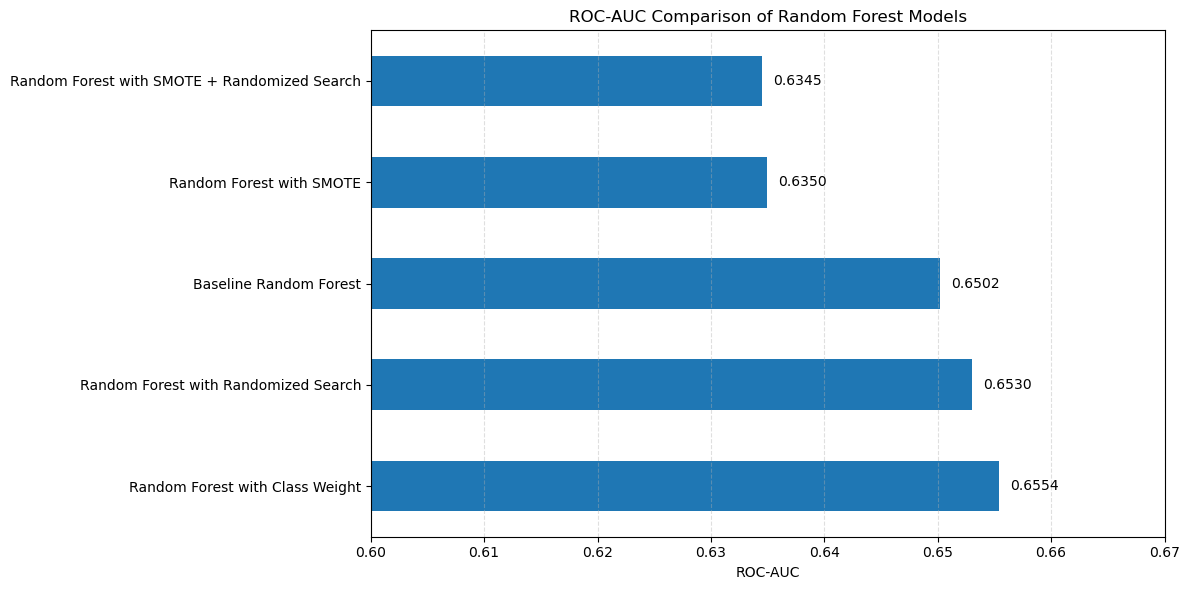

In [65]:
# Visualize model performance based on ROC-AUC.
ax = df_compare.plot.barh(
    x="Model",
    y="ROC-AUC",
    figsize=(12, 6),
    legend=False
)

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_width():.4f}",
        (bar.get_width(), bar.get_y() + bar.get_height() / 2),
        xytext=(8, 0),
        textcoords="offset points",
        va="center"
    )

ax.set_xlim(0.60, 0.67)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.title("ROC-AUC Comparison of Random Forest Models")
plt.xlabel("ROC-AUC")
plt.ylabel("")
plt.tight_layout()
plt.show()

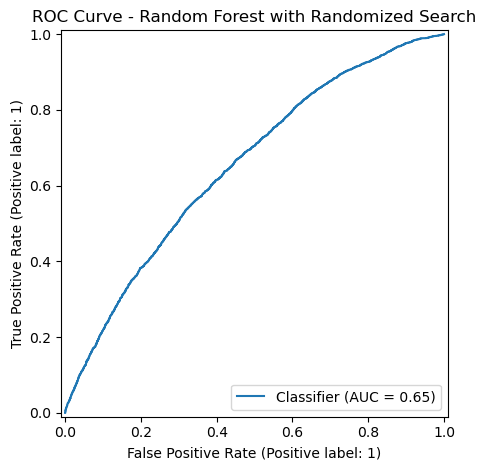

In [70]:
# Select the final model based on churn detection performance.
# Although the class-weighted model achieved the highest ROC-AUC,
# the randomized search model achieved much higher recall and F1 score,
# making it more suitable for identifying customers likely to churn.

best_model_name = "Random Forest with Randomized Search"

final_model = random_search_rf.best_estimator_
best_prob = random_search_prob

# Plot the ROC curve of the selected model.
RocCurveDisplay.from_predictions(y_valid, best_prob)
plt.title(f"ROC Curve - {best_model_name}")
plt.tight_layout()
plt.show()

### Feature Importance

Identify the most influential features used by the selected Random Forest model to predict customer churn.

In [71]:
feature_importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": final_model.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

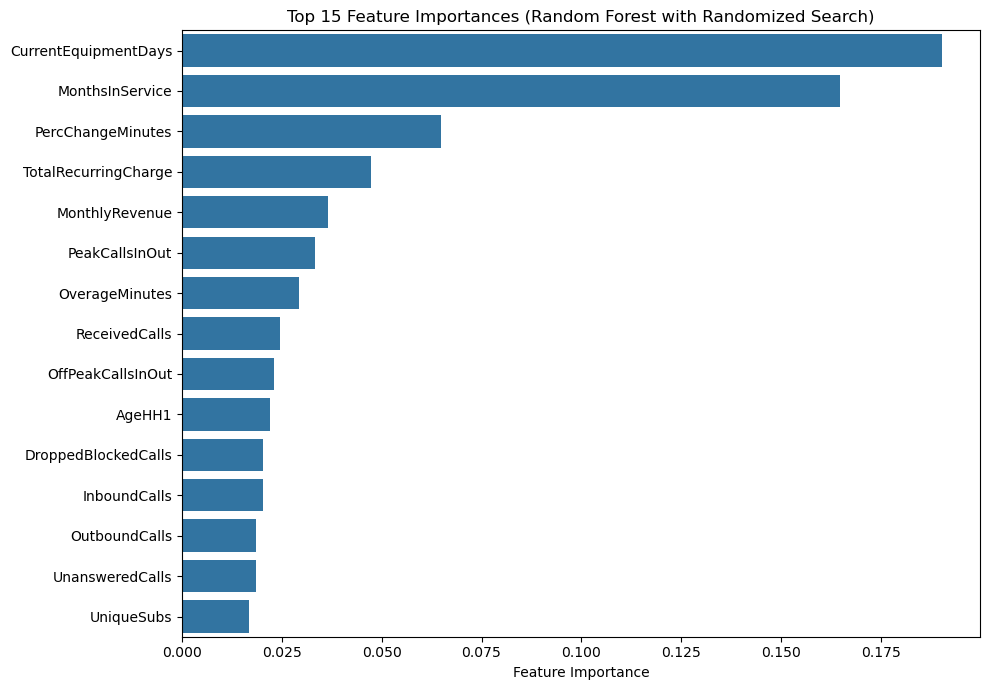

In [72]:
# Visualize the 15 most important features.
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(f"Top 15 Feature Importances ({best_model_name})")
plt.xlabel("Feature Importance")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Feature Importance Insights

- Customer tenure and equipment age were the two most influential predictors of churn.
- Changes in usage behavior and recurring charges also contributed substantially to model predictions.
- These findings suggest that customer lifecycle and behavioral signals are more informative than demographic characteristics for identifying churn risk.

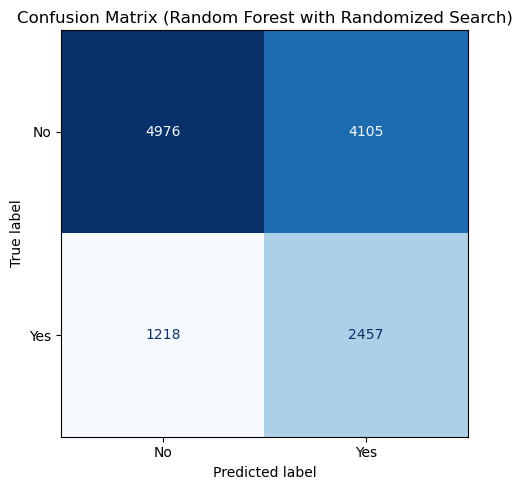

In [73]:
# Generate predictions from the selected model.
y_pred = final_model.predict(X_valid)

# Visualize the confusion matrix.
fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred,
    display_labels=["No", "Yes"],
    cmap="Blues",
    colorbar=False,
    ax=ax
)

plt.title(f"Confusion Matrix ({best_model_name})")
plt.tight_layout()
plt.show()

## Final Insights

Five Random Forest models were compared using Precision, Recall, F1 Score, and ROC-AUC.

Although the Random Forest with Class Weight achieved the highest ROC-AUC (0.6554), its Recall was very low, meaning that it failed to identify most customers who actually churned.

The Random Forest with Randomized Search was selected as the final model because it achieved a comparable ROC-AUC while substantially improving Recall and F1 Score. For customer churn prediction, identifying customers at risk of leaving is generally more valuable than maximizing ROC-AUC alone.

Feature importance analysis showed that customer tenure, device age, changes in usage patterns, recurring charges, and monthly revenue were the strongest predictors of churn. These findings suggest that both customer lifecycle and behavioral changes play important roles in customer retention.

From a business perspective, this model can be used to identify high-risk customers and prioritize proactive retention campaigns before customers leave the service.